# Louvain-only analysis of the firearm-homicide knowledge graph

## Purpose

This notebook documents the **Louvain-only configuration** used to identify communities in the firearm-homicide knowledge graph and to connect those graph communities with their spatial distribution in Mexico City. The paper uses this configuration as a baseline against which DBSCAN-only and sequential hybrid configurations can be compared.

The computational workflow has four layers:

1. **Data preparation:** load homicide records and AGEB-level contextual data, restrict the study period to 2017–2022, and derive demographic variables.
2. **Graph community detection:** load the serialized knowledge graph and apply Louvain modularity optimization with a fixed random state.
3. **Community characterization:** calculate structural measures, recover homicide-record identifiers from graph nodes, and reconnect communities to the original tabular and geographic records.
4. **Cartographic post-processing:** restrict the display to Iztapalapa, overlay records on AGEB polygons, and explore distance- and poverty-constrained spatial groupings.

> **Scope note.** Only the modularity-based partition is produced by Louvain. The later distance, poverty, seed-selection, and polygon-mapping steps are **post-processing procedures** and should not be described as part of the Louvain algorithm itself.

## Reproducibility

- Main random state for Louvain: `123`.
- Random state for the force-directed network layout: `142`.
- Coordinate reference system used for point mapping: `EPSG:4326`.
- Geographic focus of the cartographic examples: Iztapalapa (`CVEGEO` containing `09007`).
- The notebook preserves the original code and stored outputs. The added Markdown and `Annotation` comments explain the role of each cell without altering its calculations.


In [1]:
# Annotation: Import numerical, graph, RDF, clustering, and geospatial libraries used across the workflow.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
import numpy as np
import math
import pandas as pd
from shapely.geometry import Polygon, LineString, Point, MultiPolygon
import rdflib
from rdflib import Namespace, URIRef, BNode
from rdflib.namespace import RDF, FOAF, OWL, RDFS, XSD
from time import time #importamos la función time para capturar tiempos
import ontospy
from ontospy import *
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
#import kglab
import os
import igraph as ig
import leidenalg as la
import community as community_louvain
import networkx.algorithms.community as nx_comm
import geopandas as gpd
import json
from sklearn.cluster import DBSCAN 

## 1. Data inputs and preprocessing

The analysis expects the following local inputs:

| File | Role in the workflow |
|---|---|
| `homicidioscdmx.csv` | Incident- and victim-level homicide records, including identifiers, dates, demographic attributes, coordinates, and borough labels. |
| `agebspob.csv` | AGEB-level tabular contextual information. It is loaded here but is not used in the executed Louvain path shown below. |
| `ageb_pobreza.shp` | AGEB polygons and poverty categories used for the spatial overlay. |
| `grafoarmfuego4.json` | Serialized NetworkX knowledge graph on which Louvain is applied. |
| `total.shp` | Additional population layer loaded during exploratory spatial post-processing. |

Missing sex and neighborhood values are retained as explicit categories. Missing ages are temporarily recoded as zero in the original implementation; this causes them to enter the first age group and should be considered when interpreting demographic summaries.


In [2]:
# Annotation: Load homicide records and AGEB-level contextual data from CSV files.
carpetas=pd.read_csv('homicidioscdmx.csv')
agebinfo=pd.read_csv('agebspob.csv')

In [3]:
# Annotation: Replace missing neighborhood, sex, and age values with an explicit 'No especificado' category.
carpetas['colonia_datos'].replace(np.NaN,'No especificado',inplace=True)
carpetas['Sexo'].replace(np.NaN,'No especificado',inplace=True)
carpetas['Edad'].replace(np.NaN,'No especificado',inplace=True)


In [4]:
# Annotation: Restrict incidents to 2017–2022 and inspect the resulting schema and non-null counts.
carpetas=carpetas[(carpetas['Año_hecho']>=2017) & (carpetas['Año_hecho']<=2022)]
carpetas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          4021 non-null   int64  
 1   index                 4021 non-null   int64  
 2   Unnamed: 0            4021 non-null   int64  
 3   idCarpeta             4021 non-null   float64
 4   Año_inicio            4021 non-null   int64  
 5   Mes_inicio            4021 non-null   object 
 6   FechaInicio           4021 non-null   object 
 7   Delito                4021 non-null   object 
 8   Categoria             4021 non-null   object 
 9   Sexo                  4021 non-null   object 
 10  Edad                  4021 non-null   object 
 11  TipoPersona           4017 non-null   object 
 12  CalidadJuridica       4021 non-null   object 
 13  competencia           4021 non-null   object 
 14  Año_hecho             4021 non-null   float64
 15  Mes_hecho            

In [5]:
# Annotation: Create radian coordinates and encoded age-group, sex, and year variables for later analysis.
carpetas['longitudrad'] = np.radians(carpetas.longitud)
carpetas['latitudrad'] = np.radians(carpetas.latitud)
carpetas.Edad.replace('No especificado','0.0',inplace=True)
carpetas.Edad = carpetas.Edad.astype(float)
carpetas.Edad = carpetas.Edad.astype(int)
edades = [0, 18, 64, float('inf')]
# Etiquetas para los grupos etarios
etiquetas_edad = ['0-18', '19-64', '65+']
mapeo2 = {'0-18': 1, '19-64': 2, '65+': 3}


carpetas['grupo_etario'] = pd.cut(carpetas['Edad'], bins=edades, labels=etiquetas_edad, right=False)
carpetas['grupo_etario2'] = carpetas['grupo_etario'].map(mapeo2)
carpetas['genero2'] = carpetas['Sexo'].replace({'Masculino':1,'Femenino':2,'No especificado':3})
carpetas['año'] = carpetas['Año_hecho']


In [6]:
# Annotation: Display the preprocessed homicide table for an exploratory quality check.
carpetas

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitud,longitud,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año
0,0,188,192,8325049.0,2019,Enero,2019-01-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.237800,-99.144230,0813,NaN,-1.730393,0.335763,19-64,2,1,2019.0
1,1,384,389,8325655.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.395180,-99.193390,1773,NaN,-1.731251,0.338510,19-64,2,1,2019.0
2,2,454,460,8325855.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.366760,-99.087920,0750,NaN,-1.729410,0.338014,19-64,2,1,2019.0
3,3,512,520,8326053.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.272320,-99.135920,0067,NaN,-1.730248,0.336365,19-64,2,1,2019.0
4,4,519,527,8326074.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.309127,-99.206300,1307,NaN,-1.731477,0.337008,19-64,2,1,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,4140,965826,973633,9361524.0,2022,Diciembre,2022-12-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.441201,-99.119868,0371,NaN,-1.729968,0.339313,0-18,1,1,2022.0
4017,4141,968068,978150,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,1,2022.0
4018,4142,968069,978151,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,0-18,1,1,2022.0
4019,4143,968070,978152,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,2,2022.0


## 2. Geographic reference layer

The AGEB poverty shapefile is converted to geographic coordinates (`EPSG:4326`) so that its polygons can be overlaid with homicide-record points stored as longitude and latitude.


In [7]:
# Annotation: Load AGEB poverty polygons and harmonize their CRS with longitude/latitude incident coordinates.
alcal=gpd.read_file('ageb_pobreza.shp')
alcal=alcal.to_crs('EPSG:4326')

ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


<Axes: >

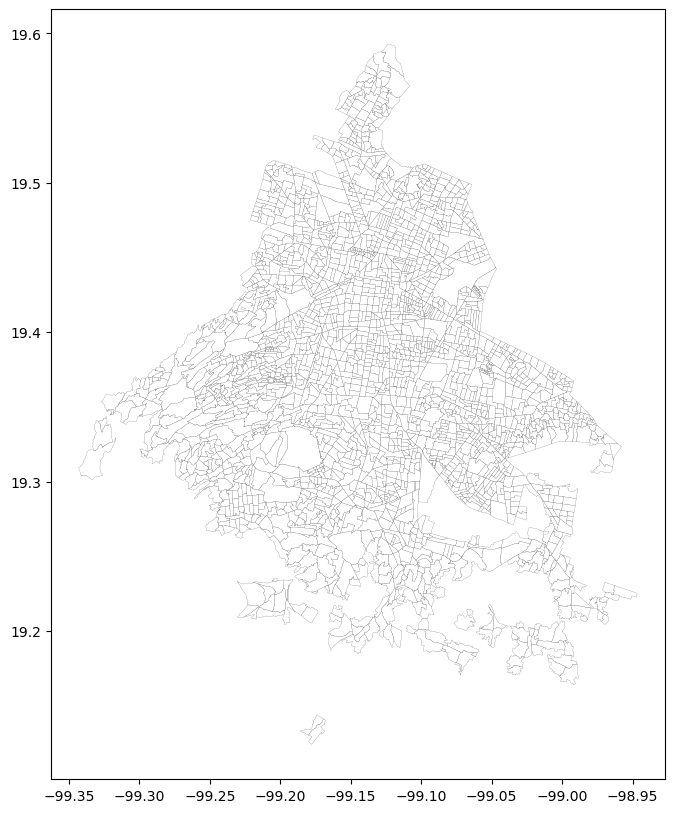

In [8]:
# Annotation: Plot the AGEB reference layer to verify geometry coverage and boundaries.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.1)


## 3. Helper functions for graph diagnostics

These utilities report basic graph properties, convert the node-to-community partition returned by `python-louvain` into the list-of-sets format expected by NetworkX modularity functions, and test whether each induced community subgraph is connected.


In [9]:
# Annotation: Define a utility that reports graph size, clustering, and connected-component count.
def get_graph_info(graph):
    print("Number of nodes:", graph.number_of_nodes())
    print("Number of edges:", graph.number_of_edges())
    print("Average Cluster Coefficients:", nx.average_clustering(graph))
    print("Connected components:", len(list(nx.connected_components(graph))))

In [10]:
# Annotation: Convert a node-to-community dictionary into the community-list representation used by NetworkX.
 
def convert_communities_dict_to_list(communities_dict):
    unique_partition_count = len(list(set(communities_dict.values())))
    print("Number of unique communities:", unique_partition_count)
    communities = [[] for i in range(unique_partition_count)]
    for node in communities_dict.keys():
        communities[communities_dict[node]].append(node)
    return communities

In [11]:
# Annotation: Define a diagnostic that checks whether every induced community subgraph is connected.
# function to check whether the determined communities are connected
def check_community_disconnection(graph, communities):
    total_connected = 0
    disconnected_community_indexes = []
    for i in range(len(communities)):
        if nx.is_connected(graph.subgraph(communities[i])):
            total_connected += 1
        else:
            disconnected_community_indexes.append(i)
    print("Total Communities:", len(communities))
    print("Total Communities Connected:", total_connected)
    print("Disconnected Community Indexes:", disconnected_community_indexes)

## 4. Knowledge-graph loading and exploratory inspection

The JSON file is reconstructed as a NetworkX graph. The following cells verify its size and inspect selected URI nodes and their immediate neighborhood. This local subgraph is a qualitative illustration of the ontology-linked structure; it is not the community-detection result.


In [12]:
# Annotation: Deserialize the knowledge graph from NetworkX node-link JSON format.
# Carga el grafo desde el archivo JSON
with open("grafoarmfuego4.json", "r") as json_file:
    graph_data = json.load(json_file)

# Crea un grafo de NetworkX a partir de los datos cargados
G = nx.readwrite.json_graph.node_link_graph(graph_data)


In [13]:
# Annotation: Verify that the firearm-homicide concept URI exists in the graph.
'http://localhost/HOMICIDIO_POR_ARMA_DE_FUEGO' in list(G.nodes())

True

In [14]:
# Annotation: Report the number of graph nodes and edges.
# Número de nodos y enlaces
num_nodos = G.number_of_nodes()
num_enlaces = G.number_of_edges()

print("Número de nodos:", num_nodos)
print("Número de enlaces:", num_enlaces)



Número de nodos: 12938
Número de enlaces: 46557


In [15]:
# Annotation: Count nodes whose URI or label contains the string 'HOMICIDIO'.
import networkx as nx

# Supongamos que G es tu grafo
nodos_homicidio = [nodo for nodo in G.nodes if 'HOMICIDIO' in nodo]
print(len(nodos_homicidio))


2


In [16]:
# Annotation: Inspect the first neighbour of the selected AGEB node as a local graph sanity check.
#vecin = list(G.neighbors('http://localhost/0'))
vecin2 = list(G.neighbors( 'http://localhost/AGEB0813'))
vecin2[0]

'http://localhost/ontology2#Lugar'

In [17]:
# Annotation: Build an induced subgraph from the neighbours of the selected AGEB node.
vecino=[]
#for i in range(0,len(vecin)):
 #   vecino.append(vecin[i])

for i in range(0,len(vecin2)):
    vecino.append(vecin2[i])

subg=G.subgraph(vecino)


In [18]:
# Annotation: Display the neighbour-node list used in the illustrative subgraph.
vecino

['http://localhost/ontology2#Lugar',
 '[ 50, 70]',
 'http://localhost/ontology2#AGEB',
 '0',
 '4180',
 '12615',
 '1848',
 "(array('d', [-99.1439938497202]), array('d', [19.2394036202517]))",
 'http://localhost/8652886',
 'http://localhost/9074988',
 '65',
 'http://localhost/8325049',
 "(array('d', [-99.1440414197777]), array('d', [19.2425142290385]))",
 'http://localhost/9223798',
 "(array('d', [-99.1438013876185]), array('d', [19.2351378783241]))",
 "(array('d', [-99.14423]), array('d', [19.2378]))"]

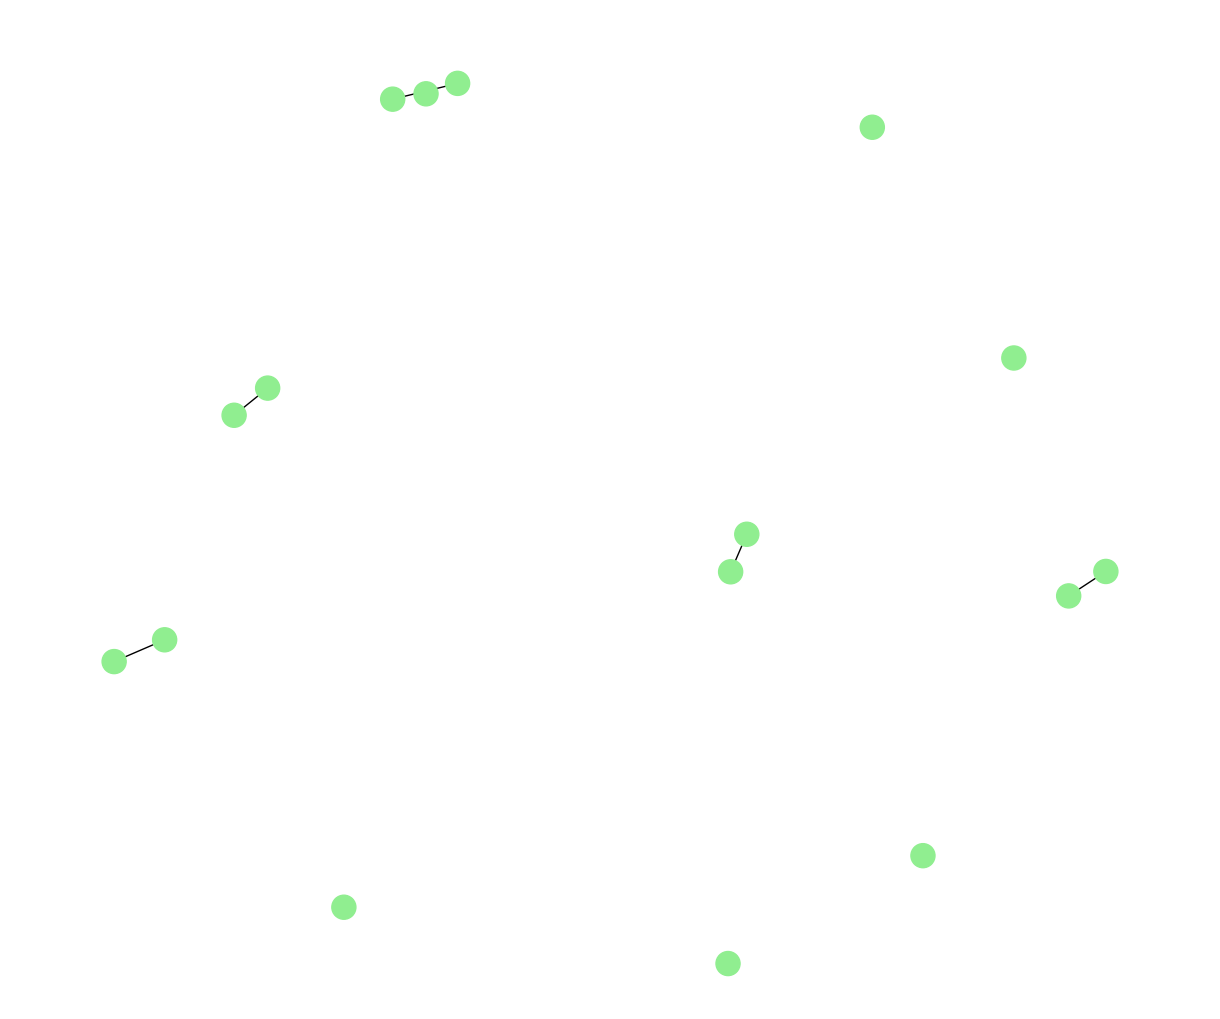

In [19]:
# Annotation: Draw and save the illustrative AGEB-neighbourhood subgraph with semantic node colors.
# Plotear el subgrafo
import matplotlib.pyplot as plt

# Definir el tamaño de los nodos y los labels
node_size = 300  # Tamaño de los nodos
font_size = 8  # Tamaño de los labels

colors = []
for nodo in subg.nodes():
    if nodo == 'http://localhost/0':
        colors.append('red')  # Color rojo para el nodo 'Masculino'
    elif nodo == 'http://localhost/HOMICIDIO_POR_ARMA_DE_FUEGO':
        colors.append('blue')  # Color azul para este nodo
    elif nodo == 'http://localhost/AGEB0813':
        colors.append('green')  # Color azul para este nodo
    else:
        colors.append('lightgreen')  # Color verde claro para los demás nodos

# Dibujar el subgrafo con los parámetros ajustados
plt.figure(figsize=(12, 10))  # Opcional: ajustar el tamaño de la figura
nx.draw(subg, with_labels=False, node_size=node_size, font_size=font_size, node_color=colors, font_weight='bold')
plt.savefig('Fig1Louvain.jpg',format='JPEG')
plt.show()


## 5. Louvain community detection

`community_louvain.best_partition` assigns every graph node to a community by optimizing modularity. Fixing `random_state=123` makes the stochastic partition reproducible under the same graph, package version, and runtime environment. NetworkX then evaluates the partition's modularity, while the histogram summarizes the distribution of community sizes.


In [20]:
# Annotation: Run Louvain modularity optimization on the full graph with a fixed random state.
louvain_communitiesrdf = community_louvain.best_partition(G, random_state=123)

In [21]:
# Annotation: Convert the Louvain partition into lists of nodes, one list per community.
louvain_communities2rdf = convert_communities_dict_to_list(louvain_communitiesrdf)
louvain_communities2rdf

Number of unique communities: 73


[['http://localhost/8671489',
  'http://localhost/8620888',
  '2020-01-28',
  'http://localhost/AGEB0984',
  '214715',
  'http://localhost/8561850',
  'http://localhost/9204238',
  'http://localhost/8734405',
  'http://localhost/9340319',
  'http://localhost/8823936',
  'http://localhost/AGEB1523',
  'http://localhost/9340422',
  'http://localhost/AGEB5677',
  'http://localhost/8562027',
  '5471',
  'http://localhost/AGEB0584',
  'http://localhost/AGEB1042',
  '5802',
  'http://localhost/8422890',
  "(array('d', [-99.2303]), array('d', [19.34924]))",
  'http://localhost/8982044',
  'http://localhost/AGEB1427',
  'http://localhost/8561674',
  'http://localhost/8805624',
  "(array('d', [-99.2118837404413]), array('d', [19.3801153466799]))",
  "(array('d', [-99.2696696496166]), array('d', [19.3039752295023]))",
  '16639',
  "(array('d', [-99.03024]), array('d', [19.33829]))",
  'http://localhost/AGEB1078',
  'http://localhost/AGEB2574',
  "(array('d', [-99.13635]), array('d', [19.53127]))

In [22]:
%%time
# Annotation: Calculate and report modularity for the Louvain partition while recording runtime.

# take a look at the modularity of the Louvain algorithm output
print("Modularity:", 
      round(nx_comm.modularity(G, louvain_communities2rdf), 6))

Modularity: 0.400476
CPU times: total: 46.9 ms
Wall time: 52.1 ms


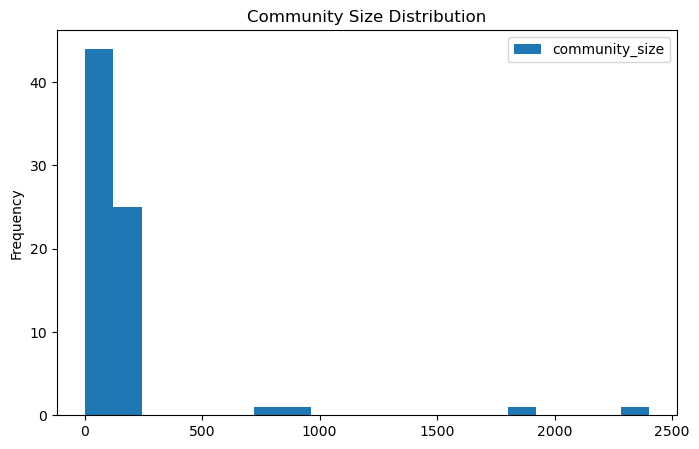

In [23]:
# Annotation: Visualize the distribution of Louvain community sizes.
community_sizes = pd.DataFrame([len(community) for community in louvain_communities2rdf], 
                               columns=["community_size"])
community_sizes.plot.hist(bins=20, figsize=(8,5), title="Community Size Distribution");

## 6. Structural characterization of Louvain communities

Each Louvain community is converted into an induced subgraph and then into an undirected igraph object. The notebook calculates mean closeness, mean betweenness, the node with maximum betweenness, edge and node counts, and average shortest-path length for each community.

These statistics describe internal structure rather than partition quality. In particular, raw igraph betweenness is scale-dependent, so comparisons between communities of very different sizes should be interpreted cautiously.


In [24]:
# Annotation: Create a dictionary that maps each community label to its member-node list.
def get_communities_lists(community_dict):
    communities_lists = {}  # Un diccionario donde las claves son los números de comunidad y los valores son las listas de nodos
    for node, community in community_dict.items():
        if community not in communities_lists:
            communities_lists[community] = []
        communities_lists[community].append(node)
    return communities_lists

# Ejemplo de cómo usar la función para obtener todas las comunidades en diferentes listas
all_communities_lists = get_communities_lists(louvain_communitiesrdf)



In [25]:
# Annotation: Inspect the number of nodes assigned to community 0.
len(all_communities_lists[0])

123

In [26]:
# Annotation: Construct each community subgraph and calculate closeness, betweenness, central node, and path statistics.
# Crear un diccionario para almacenar los subgrafos y sus medidas de centralidad
subgrafos_y_centralidad = {}

# Iterar a través de cada comunidad y crear un subgrafo en NetworkX
for comunidad, nodos in all_communities_lists.items():
    subgrafo_nx = G.subgraph(nodos)  # G es tu grafo original de NetworkX
    
    # Convertir el subgrafo de NetworkX a igraph
    subgrafo_ig = ig.Graph(directed=False)
    
    # Agregar nodos con índices únicos para igraph
    node_mapping = {}  # Diccionario para mapear nodos originales a índices en igraph
    for nodo in subgrafo_nx.nodes():
        idx = subgrafo_ig.add_vertex()  # Agregar un nodo en igraph y obtener su índice
        node_mapping[nodo] = idx  # Asociar el nodo original con el índice en igraph
    
    # Agregar aristas con índices únicos
    for edge in subgrafo_nx.edges():
        source = node_mapping[edge[0]]
        target = node_mapping[edge[1]]
        subgrafo_ig.add_edge(source, target)
        
    # Crear el mapeo inverso de índices a URIs
    index_to_uri_mapping = {index: uri for uri, index in node_mapping.items()}
    
    
    closeness=subgrafo_ig.closeness()
    average_closeness = sum(closeness) / subgrafo_ig.vcount()
    centralidad = subgrafo_ig.betweenness()  # Calcular la centralidad que desees
    most_central_node1 = centralidad.index(max(centralidad))
    centralidad = sum(centralidad) / subgrafo_ig.vcount()
    
    for vertex, uri in index_to_uri_mapping.items():
        index_number = int(str(vertex).split()[-2].replace(',',''))
        if index_number==most_central_node1:
            nodouri=uri
    subgrafos_y_centralidad[comunidad] = {
        'subgrafo': subgrafo_ig,
        'centralidad': centralidad,
        'closeness' : average_closeness,
        'nodo central': most_central_node1,
        'uri': nodouri,
        'mapeo':index_to_uri_mapping
    }

# Ahora puedes acceder a los subgrafos y medidas de centralidad por comunidad
for comunidad, data in subgrafos_y_centralidad.items():
    print(f"Comunidad: {comunidad}")
    print("Centralidad:", data['centralidad'])
    print('closeness: ',data['closeness'])
    print("Número de nodos en el subgrafo:", data['subgrafo'].vcount())
    print("Número de enlaces en el subgrafo:", data['subgrafo'].ecount())
    print('Shortest path', data['subgrafo'].average_path_length())
    print('central node',data['nodo central'])
    print('nodo uri',data['uri'])
    print("-----")

Comunidad: 0
Centralidad: 560.3658536585366
closeness:  0.10291888061155641
Número de nodos en el subgrafo: 123
Número de enlaces en el subgrafo: 141
Shortest path 10.186325469812076
central node 14
nodo uri 118
-----
Comunidad: 1
Centralidad: 1702.484110169494
closeness:  0.367931754589888
Número de nodos en el subgrafo: 1888
Número de enlaces en el subgrafo: 8590
Shortest path 2.8044346689660746
central node 809
nodo uri http://localhost/ontology2#obs
-----
Comunidad: 9
Centralidad: 537.9532710280373
closeness:  0.16981090595898635
Número de nodos en el subgrafo: 214
Número de enlaces en el subgrafo: 256
Shortest path 6.051204422798473
central node 98
nodo uri 55
-----
Comunidad: 3
Centralidad: 364.6185567010309
closeness:  0.12052834002524171
Número de nodos en el subgrafo: 97
Número de enlaces en el subgrafo: 110
Shortest path 8.596219931271477
central node 52
nodo uri 56
-----
Comunidad: 4
Centralidad: 486.4825174825174
closeness:  0.1303426137806917
Número de nodos en el subgrafo

In [27]:
# Annotation: Check whether the bladed-weapon homicide concept belongs to community 2.
'http://localhost/HOMICIDIO_POR_ARMA_BLANCA' in all_communities_lists[2]

False

In [28]:
# Annotation: Collect mean betweenness values by community for comparison.
centralidades=[]
for comunidad, data in subgrafos_y_centralidad.items():
    com= comunidad
    centr= data['centralidad']
    centralidades.append([com,centr])



> **Annotation:** Retain an exploratory heading from the original notebook.

## subgrafos_y_centralidad[0]

In [29]:
# Annotation: Display community centrality values ordered by community label.
sorted(centralidades)

[[0, 560.3658536585366],
 [1, 1702.484110169494],
 [2, 0.0],
 [3, 364.6185567010309],
 [4, 486.4825174825174],
 [5, 1083.793672627235],
 [6, 602.4915611814389],
 [7, 298.45255474452557],
 [8, 442.5357142857143],
 [9, 537.9532710280373],
 [10, 540.1496062992126],
 [11, 260.3191489361702],
 [12, 3202.2940441482733],
 [13, 676.0829875518673],
 [14, 392.4154929577465],
 [15, 181.56410256410257],
 [16, 255.04166666666666],
 [17, 274.968085106383],
 [18, 564.2364864864865],
 [19, 377.8859649122807],
 [20, 493.1],
 [21, 433.2887323943661],
 [22, 493.36486486486484],
 [23, 263.3882352941176],
 [24, 174.21276595744683],
 [25, 297.0081967213115],
 [26, 511.08227848101274],
 [27, 441.469696969697],
 [28, 319.2115384615385],
 [29, 242.49367088607596],
 [30, 632.1081081081081],
 [31, 226.43037974683546],
 [32, 568.6923076923077],
 [33, 540.8488372093024],
 [34, 407.34736842105264],
 [35, 232.28571428571425],
 [36, 42.115384615384606],
 [37, 206.2027027027027],
 [38, 256.92857142857144],
 [39, 680.9

In [30]:
# Annotation: Inspect all graph nodes assigned to community 1.
all_communities_lists[1]

['http://localhost/HOMICIDIO_POR_ARMA_DE_FUEGO',
 'http://localhost/8790171',
 'http://localhost/TLALPAN',
 'http://localhost/8419671',
 'Masculino',
 'http://localhost/9098648',
 'Femenino',
 'http://localhost/8858636',
 'http://localhost/8454529',
 'http://localhost/ontology2#obs',
 'http://localhost/8933458',
 '21.0',
 'http://localhost/8553594',
 'http://localhost/8999578',
 'http://localhost/8521818',
 'http://localhost/8430914',
 'http://localhost/9258858',
 'http://localhost/9284563',
 '23.0',
 'http://localhost/8861181',
 'http://localhost/HOMICIDIO_DOLOSO',
 'http://localhost/8612469',
 'http://localhost/8590890',
 'http://localhost/8994093',
 '2021-08-13',
 'http://localhost/8399323',
 'http://localhost/8483350',
 'http://localhost/8629421',
 'http://localhost/8897650',
 'http://localhost/CONSEJO_AGRARISTA_MEXICANO_I_IZTAPALAPA',
 'http://localhost/8692882',
 'http://localhost/9039987',
 'http://localhost/VENUSTIANO_CARRANZA',
 'http://localhost/8322550',
 'http://localhost/8

## 7. Link graph communities back to homicide records

Incident nodes are recognized by the URI pattern `http://localhost/<numeric_id>`. Their numeric suffixes are matched to `idCarpeta` in the original homicide table, producing one DataFrame per Louvain community and then a combined table carrying a `comunidad` label.


In [31]:
# Annotation: Extract numeric incident URIs from each community and convert their suffixes to case identifiers.
import re

patron = re.compile(r'^http://localhost/(\d+)$')
ids={}
n_num=[]
for community, ele in all_communities_lists.items():
    #print(ele)# Filtrar los nodos que cumplen con esa condición
    nodos_numericos = [n for n in ele if isinstance(n, str) and patron.match(n)]
    n_num.extend(nodos_numericos)
    print(nodos_numericos)
    #Extraer el número, convertirlo a float
    resultados = [float(url.split('/')[-1]) for url in nodos_numericos]
    ids[community]=resultados

#print(nodos_numericos)

['http://localhost/8671489', 'http://localhost/8620888', 'http://localhost/8561850', 'http://localhost/9204238', 'http://localhost/8734405', 'http://localhost/9340319', 'http://localhost/8823936', 'http://localhost/9340422', 'http://localhost/8562027', 'http://localhost/8422890', 'http://localhost/8982044', 'http://localhost/8561674', 'http://localhost/8805624', 'http://localhost/8839880', 'http://localhost/8879140', 'http://localhost/8422482', 'http://localhost/9052071', 'http://localhost/9035069', 'http://localhost/8734070', 'http://localhost/9340341']
['http://localhost/8790171', 'http://localhost/8419671', 'http://localhost/9098648', 'http://localhost/8858636', 'http://localhost/8454529', 'http://localhost/8933458', 'http://localhost/8553594', 'http://localhost/8999578', 'http://localhost/8521818', 'http://localhost/8430914', 'http://localhost/9258858', 'http://localhost/9284563', 'http://localhost/8861181', 'http://localhost/8612469', 'http://localhost/8590890', 'http://localhost/

In [32]:
# Annotation: Define a matcher that retrieves homicide-table rows for every community's case identifiers.
def getdatafromids(data, dictids):
    dataids = {}
    for community, elements in dictids.items():
        dataids[community] = pd.DataFrame()  # Crear un DataFrame vacío para cada comunidad
        for ele in elements:
            ele=float(ele)
            
            row = data[data['idCarpeta']==ele]
            print(row)
            dataids[community] = pd.concat([dataids[community],row])
    return dataids

# Crea un diccionario vacío para almacenar los DataFrames por comunidad

In [33]:
# Annotation: Apply the case-identifier matcher to create one incident DataFrame per Louvain community.
dfcomun=getdatafromids(carpetas,ids)

      Unnamed: 0.1   index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
1668          1703  328256      331616  8671489.0        2020      Abril   

     FechaInicio                       Delito         Categoria       Sexo  \
1668  2020-04-02  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino   

      ...    latitud   longitud  ageb shp  longitudrad latitudrad  \
1668  ...  19.474505 -99.208133  1042 NaN    -1.731509   0.339894   

     grupo_etario grupo_etario2 genero2     año  
1668        19-64             2       1  2020.0  

[1 rows x 33 columns]
      Unnamed: 0.1   index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
1439          1468  280868      283798  8620888.0        2020      Enero   

     FechaInicio                       Delito         Categoria       Sexo  \
1439  2020-01-28  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino   

      ...    latitud   longitud  ageb shp  longitudrad latitudrad  \
1439  ...  19.347864 -99.231858  1078 NaN    -1.7

In [34]:
# Annotation: Inspect the records associated with community 0.
dfcomun[0]

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitud,longitud,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año
1668,1703,328256,331616,8671489.0,2020,Abril,2020-04-02,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.474505,-99.208133,1042,NaN,-1.731509,0.339894,19-64,2,1,2020.0
1439,1468,280868,283798,8620888.0,2020,Enero,2020-01-28,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.347864,-99.231858,1078,NaN,-1.731923,0.337684,19-64,2,1,2020.0
767,787,143591,145111,8561850.0,2019,Noviembre,2019-11-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.338290,-99.030240,2901,NaN,-1.728404,0.337517,0-18,1,1,2019.0
3592,3695,816801,823665,9204238.0,2022,Mayo,2022-05-31,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.380115,-99.211884,1523,NaN,-1.731574,0.338247,19-64,2,1,2022.0
2092,2142,387315,391011,8734405.0,2020,Agosto,2020-08-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.301629,-99.078338,3505,NaN,-1.729243,0.336877,19-64,2,1,2020.0
3949,4071,945620,953315,9340319.0,2022,Noviembre,2022-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.268425,-99.007475,1427,NaN,-1.728006,0.336297,65+,3,1,2022.0
2456,2516,471252,475610,8823936.0,2020,Diciembre,2020-12-22,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.377293,-99.122394,0322,NaN,-1.730012,0.338198,19-64,2,1,2020.0
3951,4073,945723,953418,9340422.0,2022,Noviembre,2022-11-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19.366218,-99.033909,5677,NaN,-1.728468,0.338004,19-64,2,2,2022.0
768,788,143644,145164,8562027.0,2019,Noviembre,2019-11-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.308780,-99.169850,1622,NaN,-1.730840,0.337002,19-64,2,1,2019.0
1274,1299,248566,251150,8422890.0,2019,Mayo,2019-05-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.349240,-99.230300,1078,NaN,-1.731895,0.337708,0-18,1,1,2019.0


In [35]:
# Annotation: Concatenate community DataFrames and retain the Louvain label in a new column.
import pandas as pd

# Supongamos que df_comun es tu diccionario de DataFrames
# Cada DataFrame debe tener columnas 'latitud' y 'longitud'

# Lista para guardar los dataframes modificados
dataframes = []

for comunidad, df in dfcomun.items():
    df_copy = df.copy()
    df_copy["comunidad"] = comunidad  # Añade columna con el nombre de la comunidad
    dataframes.append(df_copy)

# Concatenar todos los DataFrames en uno solo
df_todo = pd.concat(dataframes, ignore_index=True)

# Verifica el resultado
print(df_todo.head())

   Unnamed: 0.1     index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
0        1703.0  328256.0    331616.0  8671489.0      2020.0      Abril   
1        1468.0  280868.0    283798.0  8620888.0      2020.0      Enero   
2         787.0  143591.0    145111.0  8561850.0      2019.0  Noviembre   
3        3695.0  816801.0    823665.0  9204238.0      2022.0       Mayo   
4        2142.0  387315.0    391011.0  8734405.0      2020.0     Agosto   

  FechaInicio                       Delito         Categoria       Sexo  ...  \
0  2020-04-02  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
1  2020-01-28  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
2  2019-11-06  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
3  2022-05-31  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
4  2020-08-08  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   

    longitud  ageb shp longitudrad  latitudrad grupo_etario grupo_et

## 8. Construct the geospatial incident layer

Longitude and latitude are converted to Shapely points and stored in a GeoDataFrame with `EPSG:4326`. The longitude filter removes clearly invalid coordinates before the analysis is restricted to Iztapalapa and duplicate case identifiers are removed.


In [36]:
# Annotation: Construct point geometries from incident longitude and latitude.
from shapely.geometry import Point

# Crear la columna de geometría
df_todo["geometry"] = df_todo.apply(lambda row: Point(row["longitud"], row["latitud"]), axis=1)


In [37]:
# Annotation: Remove records with clearly invalid longitudes for the Mexico City study area.
df_todo=df_todo[df_todo['longitud']<-20]

In [38]:
# Annotation: Convert the combined incident table into a GeoDataFrame in EPSG:4326.
import geopandas as gpd

gdf_todo = gpd.GeoDataFrame(df_todo, geometry="geometry", crs="EPSG:4326")


In [39]:
# Annotation: Display the complete geospatial incident layer.
gdf_todo

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry
0,1703.0,328256.0,331616.0,8671489.0,2020.0,Abril,2020-04-02,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1042,NaN,-1.731509,0.339894,19-64,2,1.0,2020.0,0,POINT (-99.20813 19.47451)
1,1468.0,280868.0,283798.0,8620888.0,2020.0,Enero,2020-01-28,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1078,NaN,-1.731923,0.337684,19-64,2,1.0,2020.0,0,POINT (-99.23186 19.34786)
2,787.0,143591.0,145111.0,8561850.0,2019.0,Noviembre,2019-11-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,2901,NaN,-1.728404,0.337517,0-18,1,1.0,2019.0,0,POINT (-99.03024 19.33829)
3,3695.0,816801.0,823665.0,9204238.0,2022.0,Mayo,2022-05-31,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1523,NaN,-1.731574,0.338247,19-64,2,1.0,2022.0,0,POINT (-99.21188 19.38012)
4,2142.0,387315.0,391011.0,8734405.0,2020.0,Agosto,2020-08-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,3505,NaN,-1.729243,0.336877,19-64,2,1.0,2020.0,0,POINT (-99.07834 19.30163)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,1221.0,233225.0,235586.0,8506227.0,2019.0,Agosto,2019-08-25,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,0645,NaN,-1.729674,0.338405,19-64,2,2.0,2019.0,70,POINT (-99.10303 19.38916)
4017,3665.0,807462.0,814249.0,9194285.0,2022.0,Mayo,2022-05-19,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0645,NaN,-1.728736,0.336686,19-64,2,1.0,2022.0,70,POINT (-99.04927 19.29069)
4018,3389.0,700403.0,706490.0,9078427.0,2021.0,Diciembre,2021-12-09,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,3214,NaN,-1.730064,0.341198,19-64,2,1.0,2021.0,71,POINT (-99.12535 19.54918)
4019,3012.0,592077.0,597362.0,8962611.0,2021.0,Junio,2021-06-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,3214,NaN,-1.730065,0.341199,19-64,2,1.0,2020.0,71,POINT (-99.12544 19.54927)


## 9. Restrict the cartographic analysis to Iztapalapa

The borough is identified from AGEB codes containing `09007`. A point-in-polygon test retains only incident coordinates located inside the selected polygons, providing a geographic consistency check beyond the textual borough field.


In [40]:
# Annotation: Filter records to Iztapalapa and remove duplicate case identifiers.
gdf2=gdf_todo[gdf_todo['alcaldia_hechos']=='IZTAPALAPA']
gdf2=gdf2.drop_duplicates(subset='idCarpeta')


In [41]:
# Annotation: Verify the borough labels remaining after the textual filter.
gdf2.alcaldia_hechos.unique()

array(['IZTAPALAPA'], dtype=object)

In [42]:
# Annotation: Inspect the AGEB polygon layer before spatial filtering.
alcal

,CVEGEO,POBREZA,POBREZAEX,ID,geometry
0,0900200010010,"(18, 34]","[ 0, 20]",1,"POLYGON ((-99.20307 19.51415, -99.20319 19.513..."
1,0900200010025,"[ 0, 18]","[ 0, 20]",2,"POLYGON ((-99.19662 19.51270, -99.19662 19.511..."
2,090020001003A,"[ 0, 18]","[ 0, 20]",3,"POLYGON ((-99.20658 19.51169, -99.20611 19.511..."
3,0900200010044,"[ 0, 18]","[ 0, 20]",4,"POLYGON ((-99.20530 19.51033, -99.20529 19.510..."
4,0900200010097,"[ 0, 18]","[ 0, 20]",5,"POLYGON ((-99.20573 19.50454, -99.20630 19.504..."
...,...,...,...,...,...
2427,0901700011488,"(34, 50]","[ 0, 20]",2428,"POLYGON ((-99.05931 19.42789, -99.05934 19.427..."
2428,0901700011492,"(34, 50]","[ 0, 20]",2429,"POLYGON ((-99.05931 19.42789, -99.05794 19.426..."
2429,0901700011505,"[ 0, 18]","[ 0, 20]",2430,"POLYGON ((-99.06102 19.42776, -99.05995 19.426..."
2430,090170001151A,"(18, 34]","[ 0, 20]",2431,"POLYGON ((-99.06253 19.42663, -99.06281 19.426..."


In [43]:
# Annotation: Retain only incident points geometrically contained in Iztapalapa AGEB polygons.
# 1. Filtra la alcaldía Iztapalapa
iztapa = alcal[alcal['CVEGEO'].str.contains('09007')]

# 2. Asegúrate de que ambos GeoDataFrames tengan el mismo CRS
gdf2 = gdf2.to_crs(iztapa.crs)

# 3. Crear GeoDataFrame vacío con misma estructura que gdf2
gdff = gpd.GeoDataFrame(columns=gdf2.columns, crs=gdf2.crs)

# 4. Iterar por puntos de gdf2 y verificar si están contenidos en Iztapalapa
for i in range(len(gdf2)):
    row = gdf2.iloc[[i]]  # <- usa doble corchete para que sea un DataFrame
    point = row.geometry.values[0]
    
    # Verifica si está contenido en alguno de los polígonos de iztapa
    if iztapa.contains(point).any():
        gdff = pd.concat([gdff, row], ignore_index=True)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\1499568121.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gdff = pd.concat([gdff, row], ignore_index=True)
C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\1499568121.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gdff = pd.concat([gdff, row], ignore_index=True)
C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\1499568121.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries i

## 10. Select communities and produce linked network–map figures

The original workflow selects a slice of the unique community labels and builds a subgraph around their incident nodes. Network nodes and mapped incidents receive consistent community colors, allowing the graph partition and its geographic footprint to be compared visually.

> **Selection note.** `valores_unicos[9:12]` is positional and depends on the order in which labels occur. For a final reproducible figure, the intended community identifiers should be stated explicitly.


In [73]:
# Annotation: Select three community labels by their position in the unique-label array for visualization.
valores_unicos = gdff['comunidad'].unique()
primeros_5 = valores_unicos[9:12]  # o [:8] para 8 valores
gdfg = gdff[gdff['comunidad'].isin(primeros_5)]


In [74]:
# Annotation: Inspect records from a manually selected community label.
gdf2=gdff[gdff['comunidad']==15]
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry
277,2449.0,457453.0,461710.0,8809247.0,2020.0,Noviembre,2020-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1778,NaN,-1.729776,0.337509,19-64,2,1.0,2020.0,15,POINT (-99.10886 19.33784)
278,2610.0,490582.0,495085.0,8844387.0,2021.0,Enero,2021-01-28,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1778,NaN,-1.729757,0.337494,19-64,2,1.0,2021.0,15,POINT (-99.10779 19.33700)
279,4084.0,951057.0,958782.0,9345781.0,2022.0,Diciembre,2022-12-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1778,NaN,-1.729772,0.337520,19-64,2,1.0,2022.0,15,POINT (-99.10863 19.33848)
280,1982.0,361557.0,365105.0,8707114.0,2020.0,Junio,2020-06-22,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1778,NaN,-1.729668,0.337509,19-64,2,1.0,2020.0,15,POINT (-99.10266 19.33785)
281,2173.0,396077.0,399838.0,8743752.0,2020.0,Agosto,2020-08-23,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,2899,NaN,-1.728435,0.337510,19-64,2,1.0,2020.0,15,POINT (-99.03204 19.33790)
282,1962.0,359712.0,363248.0,8705262.0,2020.0,Junio,2020-06-17,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1443,NaN,-1.728993,0.337729,19-64,2,1.0,2020.0,15,POINT (-99.06400 19.35043)
283,313.0,60417.0,61107.0,8414510.0,2019.0,Abril,2019-04-28,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1778,NaN,-1.729651,0.337505,19-64,2,1.0,2019.0,15,POINT (-99.10168 19.33763)
284,1964.0,359759.0,363295.0,8705206.0,2020.0,Junio,2020-06-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,1566,NaN,-1.729856,0.337619,19-64,2,1.0,2020.0,15,POINT (-99.11343 19.34417)
285,4083.0,951021.0,958746.0,9345743.0,2022.0,Diciembre,2022-12-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,2899,NaN,-1.728488,0.337500,19-64,2,1.0,2022.0,15,POINT (-99.03509 19.33733)
286,3325.0,681778.0,687746.0,9058570.0,2021.0,Noviembre,2021-11-12,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,2899,NaN,-1.728456,0.337459,19-64,2,1.0,2021.0,15,POINT (-99.03321 19.33499)


In [75]:
# Annotation: Display the complete Louvain community-to-node dictionary.
all_communities_lists

{0: ['http://localhost/8671489',
  'http://localhost/8620888',
  '2020-01-28',
  'http://localhost/AGEB0984',
  '214715',
  'http://localhost/8561850',
  'http://localhost/9204238',
  'http://localhost/8734405',
  'http://localhost/9340319',
  'http://localhost/8823936',
  'http://localhost/AGEB1523',
  'http://localhost/9340422',
  'http://localhost/AGEB5677',
  'http://localhost/8562027',
  '5471',
  'http://localhost/AGEB0584',
  'http://localhost/AGEB1042',
  '5802',
  'http://localhost/8422890',
  "(array('d', [-99.2303]), array('d', [19.34924]))",
  'http://localhost/8982044',
  'http://localhost/AGEB1427',
  'http://localhost/8561674',
  'http://localhost/8805624',
  "(array('d', [-99.2118837404413]), array('d', [19.3801153466799]))",
  "(array('d', [-99.2696696496166]), array('d', [19.3039752295023]))",
  '16639',
  "(array('d', [-99.03024]), array('d', [19.33829]))",
  'http://localhost/AGEB1078',
  'http://localhost/AGEB2574',
  "(array('d', [-99.13635]), array('d', [19.53127

In [76]:
# Annotation: Exploratory node-label check; this cell depends on objects defined later in the stored notebook order.
print("Ejemplo de nodos y sus comunidades:")
for i, nodo in enumerate(list(subG.nodes)[:10]):
    print(nodo, comunidad_dict.get(nodo, 'SIN COMUNIDAD'))


Ejemplo de nodos y sus comunidades:
24.0 5
(array('d', [-99.05775]), array('d', [19.38437])) 12
(array('d', [-99.130078550456]), array('d', [19.3646418655562])) 12
http://localhost/AGEB4147 12
(array('d', [-99.0402985342443]), array('d', [19.3905383685027])) 12
http://localhost/8655300 12
http://localhost/8763141 12
(array('d', [-99.0804858000842]), array('d', [19.2964839973664])) 12
http://localhost/9091256 12
28.0 1


In [77]:
# Annotation: List community labels represented by the spatially validated incident points.
gdff['comunidad'].unique()

array([0, 1, 9, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37,
       39, 40, 41, 42, 43, 44, 45, 63, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 61, 62, 64, 66, 67, 68, 69], dtype=object)

In [78]:
# Annotation: Set the random seed used by the spring-layout visualization.
SEED=142

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\4268690094.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab20", len(comunidades_presentes))
C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\4268690094.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


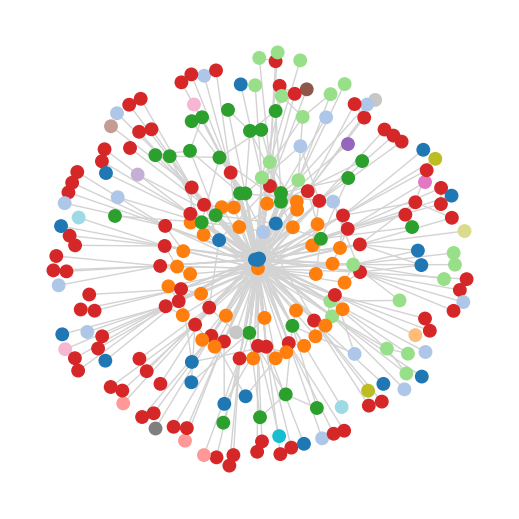

In [90]:
# Annotation: Build a local network around selected case nodes, color it by Louvain community, and save the first results figure.
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Construir diccionario nodo → comunidad a partir de all_communities_lists
comunidad_dict = {
    nodo: comunidad for comunidad, nodos in all_communities_lists.items() for nodo in nodos
}

# Convertir idCarpeta a URIs tipo http://localhost/8730058
idCarpetas_str = [f"http://localhost/{int(x)}" for x in gdfg['idCarpeta'].dropna().unique()]
max_vecinos=2
# Obtener nodos y sus vecinos
nodos_subgrafo = set()
for nodo in idCarpetas_str:
    if nodo in G:
        nodos_subgrafo.add(nodo)
        vecinos = list(G.neighbors(nodo))[:max_vecinos]  # limitar vecinos
        nodos_subgrafo.update(G.neighbors(nodo))
    else:
        print(f"⚠️ Nodo no encontrado en el grafo: {nodo}")

# Crear subgrafo
subG = G.subgraph(nodos_subgrafo).copy()

# Colores por comunidad
comunidades_presentes = sorted({comunidad_dict[n] for n in subG.nodes if n in comunidad_dict})
cmap = cm.get_cmap("tab20", len(comunidades_presentes))
com_id_map = {com: i for i, com in enumerate(comunidades_presentes)}

node_colors = [
    cmap(com_id_map[comunidad_dict[n]]) if n in comunidad_dict else (0.7, 0.7, 0.7)
    for n in subG.nodes()
]

# Dibujar
pos = nx.spring_layout(subG, seed=SEED)

plt.figure(figsize=(5, 5))
nx.draw(
    subG, pos,
    node_color=node_colors,
    edge_color='lightgray',
    node_size=80,
    with_labels=False
)
#plt.title("Subgrafo (idCarpeta + vecinos), coloreado por comunidad")
plt.axis('off')
plt.tight_layout()
plt.savefig("results1_1.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


In [80]:
# Annotation: Inspect the community labels present in the plotted network subgraph.
comunidades_presentes

[0,
 1,
 5,
 6,
 9,
 10,
 11,
 12,
 13,
 20,
 23,
 26,
 27,
 28,
 32,
 44,
 48,
 57,
 58,
 59,
 62,
 68]

In [96]:
# Annotation: Store the plotted subgraph's nodes for subsequent filtering.
nodossub=list(subG.nodes)

In [97]:
# Annotation: Display all nodes included in the plotted subgraph.
nodossub

['24.0',
 '2020-09-27',
 "(array('d', [-99.05775]), array('d', [19.38437]))",
 "(array('d', [-99.130078550456]), array('d', [19.3646418655562]))",
 'http://localhost/AGEB4147',
 "(array('d', [-99.0402985342443]), array('d', [19.3905383685027]))",
 'http://localhost/8655300',
 'http://localhost/8763141',
 "(array('d', [-98.98873]), array('d', [19.35044]))",
 '41.0',
 "(array('d', [-99.0804858000842]), array('d', [19.2964839973664]))",
 'http://localhost/9091256',
 '28.0',
 'http://localhost/AGEB383A',
 "(array('d', [-99.12261]), array('d', [19.36905]))",
 '39.0',
 'http://localhost/SANTA_CRUZ_MEYEHUALCO_(U_HAB)_I_IZTAPALAPA',
 'http://localhost/AGEB4062',
 '2020-08-19',
 'http://localhost/8741629',
 'http://localhost/AGEB1424',
 "(array('d', [-99.0644829441003]), array('d', [19.3366110229031]))",
 'http://localhost/AGEB3971',
 "(array('d', [-99.0635436798237]), array('d', [19.3248703717973]))",
 'http://localhost/AGEB038A',
 '56.0',
 "(array('d', [-99.0353820416334]), array('d', [19.346

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\2764498064.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(comunidades_presentes))  # opción más elegante
C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_30040\2764498064.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


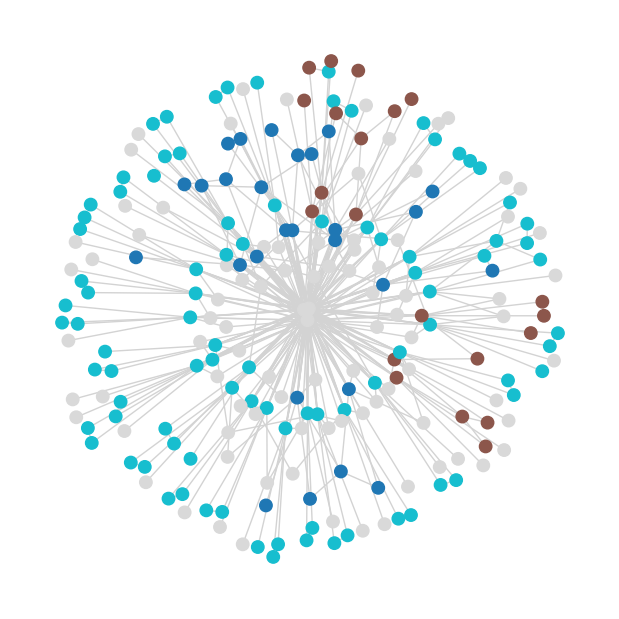

In [113]:
# Annotation: Redraw the local network while highlighting only the selected communities and greying other neighbours.
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Diccionario nodo → comunidad
comunidad_dict = {
    nodo: comunidad for comunidad, nodos in all_communities_lists.items() for nodo in nodos
}

# 2. Convertir idCarpeta a URIs
idCarpetas_str = [f"http://localhost/{int(x)}" for x in gdfg['idCarpeta'].dropna().unique()]

# 3. Construir subgrafo con vecinos
nodos_subgrafo = set()
for nodo in idCarpetas_str:
    if nodo in G:
        nodos_subgrafo.add(nodo)
        nodos_subgrafo.update(G.neighbors(nodo))
    else:
        print(f"⚠️ Nodo no encontrado en el grafo: {nodo}")

subG = G.subgraph(nodos_subgrafo).copy()

# 4. Comunidades que queremos destacar
comunidades_deseadas = set(gdfg['comunidad'].dropna().unique())

# 5. Comunidades presentes en subgrafo
comunidades_presentes = sorted(set(comunidad_dict.get(n) for n in subG.nodes if comunidad_dict.get(n) in comunidades_deseadas))

# 6. Crear colormap solo para comunidades deseadas
cmap = cm.get_cmap("tab10", len(comunidades_presentes))  # opción más elegante

com_id_map = {com: i for i, com in enumerate(comunidades_presentes)}

# 7. Asignar colores a nodos
node_colors = []
for n in subG.nodes():
    com = comunidad_dict.get(n)
    if com in comunidades_deseadas:
        color = cmap(com_id_map[com])  # color por comunidad
    else:
        color = (0.85, 0.85, 0.85)  # gris claro para nodos no destacados
    node_colors.append(color)

# 8. Layout y dibujo
pos = nx.spring_layout(subG, seed=SEED)

plt.figure(figsize=(6, 6))
nx.draw(
    subG, pos,
    node_color=node_colors,
    edge_color='lightgray',
    node_size=80,
    with_labels=False
)

plt.axis('off')
plt.tight_layout()
plt.savefig("grafo_con_comunidades_destacadas.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


In [114]:
# Annotation: Recover numeric case identifiers from the displayed network nodes and filter the geographic records accordingly.
# 1. Filtrar solo los que son URLs de idCarpeta numéricos
idCarpeta_urls = [item for item in nodossub if re.match(r'^http://localhost/\d+$', item)]

# 2. Extraer solo el número y convertir a float
idCarpeta_floats = [float(item.split('/')[-1]) for item in idCarpeta_urls]

# 3. Filtrar gdf
# Suponiendo que gdf tiene una columna llamada 'idCarpeta' con valores numéricos
filtrado = gdfg[gdfg['idCarpeta'].isin(idCarpeta_floats)]

In [115]:
# Annotation: Inspect the community labels represented in the selected geographic subset.
gdfg.comunidad.unique()

array([10, 11, 12], dtype=object)

In [116]:
# Annotation: Display the numeric incident URIs found in the network subgraph.
idCarpeta_urls

['http://localhost/8655300',
 'http://localhost/8763141',
 'http://localhost/9091256',
 'http://localhost/8741629',
 'http://localhost/8438490',
 'http://localhost/8761956',
 'http://localhost/8415500',
 'http://localhost/8733844',
 'http://localhost/8766054',
 'http://localhost/9347345',
 'http://localhost/8537342',
 'http://localhost/9257068',
 'http://localhost/8404858',
 'http://localhost/9003218',
 'http://localhost/8717406',
 'http://localhost/8499625',
 'http://localhost/8717117',
 'http://localhost/8470059',
 'http://localhost/8610022',
 'http://localhost/9256314',
 'http://localhost/8830493',
 'http://localhost/8416607',
 'http://localhost/9056593',
 'http://localhost/8560862',
 'http://localhost/9332821',
 'http://localhost/9268732',
 'http://localhost/9233233',
 'http://localhost/8418236',
 'http://localhost/8701810',
 'http://localhost/9220001',
 'http://localhost/8873036',
 'http://localhost/8371105',
 'http://localhost/9049647',
 'http://localhost/8726268',
 'http://local

In [117]:
# Annotation: Assign to each mapped incident the same color used for its Louvain community in the network figure.
# Agregar color por comunidad en gdfg
gdfg['color'] = gdfg['comunidad'].map(lambda c: cmap(com_id_map[c]) if c in com_id_map else (0.7, 0.7, 0.7))


C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


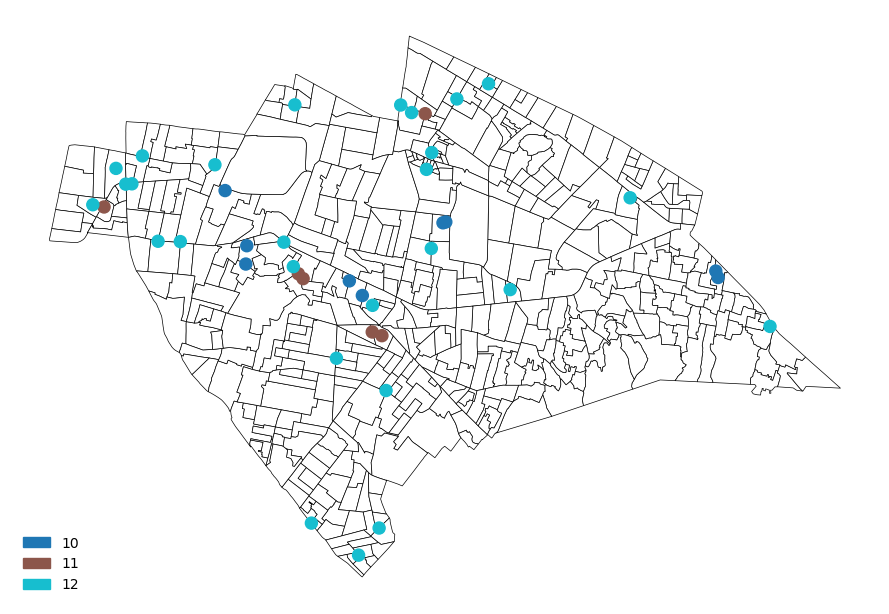

In [119]:
# Annotation: Map the selected communities over Iztapalapa and save the second results figure.
fig,ax=plt.subplots(figsize=(9,11))
alcal[alcal['CVEGEO'].str.contains('09007')].plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
# Tus puntos con color fijo
gdfg.plot(ax=ax, color=gdfg['color'], markersize=75)

# Opcional: leyenda de comunidades
import matplotlib.patches as mpatches

leyenda = [
    mpatches.Patch(color=cmap(com_id_map[com]), label=com)
    for com in comunidades_presentes
]
legend = ax.legend(handles=leyenda, loc='lower left')

# Quitar el marco
legend.get_frame().set_linewidth(0)  # quita el borde
legend.get_frame().set_facecolor('none')  # opcional: fondo transparente
plt.axis('off')
plt.tight_layout()
plt.savefig("results1_2.jpg", format='jpg', dpi=300, bbox_inches='tight')

In [386]:
# Annotation: Recheck the community labels included in the map.
gdfg.comunidad.unique()

array([3, 4, 5, 6, 7], dtype=object)

## 11. Attach AGEB poverty categories

For the selected Louvain community, each incident point is assigned the `CVEGEO` and poverty category of its containing AGEB polygon. The first loop is the cleaner implementation; the later nested loop repeats the same spatial join logic and is retained as part of the original exploratory history.


In [284]:
# Annotation: Select community 5 for the subsequent AGEB poverty exploration.
gdf2=gdfg[gdfg['comunidad']==5]
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729488,0.337997,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29..."
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.728215,0.337732,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29..."
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729136,0.336928,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29..."
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729856,0.337984,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29..."
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,NaN,-1.729975,0.337900,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29..."
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.728621,0.337723,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29..."
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.730292,0.337949,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29..."
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.729103,0.337503,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29..."
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,NaN,-1.728947,0.337603,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29..."


In [285]:
# Annotation: Assign each selected incident the AGEB code and poverty class of its containing polygon.
gdf2['CVE'] = None
gdf2['pobreza'] = None

for i in range(len(gdf2)):
    punto = gdf2.geometry.iloc[i]
    idx = gdf2.index[i]  # índice real en el DataFrame

    for j in range(len(alcal)):
        pobre = alcal.POBREZA.iloc[j]
        geom = alcal.geometry.iloc[j]
        clave = alcal.CVEGEO.iloc[j]

        if geom.contains(punto):
            gdf2.at[idx, 'CVE'] = clave
            gdf2.at[idx, 'pobreza'] = pobre
            break


C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [286]:
# Annotation: Inspect the incident records after the first polygon-overlay procedure.
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitudrad,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337997,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]"
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337732,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011710,"(34, 50]"
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.336928,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]"
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337984,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]"
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,0.337900,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]"
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337723,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]"
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337949,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]"
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337503,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]"
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337603,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011621,"(34, 50]"


In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


In [60]:
# Annotation: Repeat the point-in-polygon poverty assignment with a nested polygon-first loop.
gdf2['pobreza']=''
gdf2['CVE']=''
for i in range(0,len(alcal)):
    geom=alcal.geometry.iloc[i]
    pobre=alcal.POBREZA.iloc[i]
    cve=alcal.CVEGEO.iloc[i]
    for j in range(0,len(gdf2)):
        punto=gdf2.geometry.iloc[j]
        if geom.contains(punto):
            gdf2.loc[gdf2['geometry']==punto,'pobreza']= pobre
            gdf2.loc[gdf2['geometry']==punto,'CVE']= cve

In [287]:
# Annotation: Inspect the result of the repeated poverty assignment.
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitudrad,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337997,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]"
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337732,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011710,"(34, 50]"
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.336928,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]"
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337984,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]"
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,0.337900,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]"
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337723,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]"
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337949,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]"
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337503,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]"
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,0.337603,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011621,"(34, 50]"


In [289]:
# Annotation: Discard selected incidents that were not assigned to an AGEB poverty polygon.
gdf2=gdf2[gdf2['pobreza']!='']

In [290]:
# Annotation: List poverty categories observed in the selected community.
gdf2.pobreza.unique()

array(['(18, 34]', '(34, 50]', '[ 0, 18]', '(50, 70]'], dtype=object)

> **Annotation:** Mark the start of the revised exploratory grouping procedure.

# Nueva forma de agregar

> **Annotation:** Preserve a non-executing Markdown expression intended to inspect poverty-category counts.

gdf2['pobreza'].value_counts()

## 12. Geodesic distance matrix and candidate seed

Pairwise geodesic distances between incident points are computed in kilometres. The candidate seed is selected from the most frequent AGEB and minimizes average distance to other points in that AGEB.

> **Indexing check required.** The distance matrix is labelled with `idCarpeta`, whereas `find_central_point_by_community` reads the GeoDataFrame's row index. These identifiers must be aligned before the notebook can be rerun reliably from a clean kernel.


In [308]:
# Annotation: Compute the complete pairwise geodesic distance matrix in kilometres.
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from geopy.distance import geodesic


def geod_distance(p1, p2):
    return geodesic((p1.y, p1.x), (p2.y, p2.x)).kilometers

# Calcular la matriz de distancias geodésicas
dist_matrix_geod = [
    [geod_distance(p1, p2) for p2 in gdf2['geometry']]
    for p1 in gdf2['geometry']
]

# Convertir la matriz a un DataFrame
dist_matrix_df = pd.DataFrame(dist_matrix_geod, index=gdf2.idCarpeta, columns=gdf2.idCarpeta)

dist_matrix_df


idCarpeta,8632653.0,8399228.0,8849170.0,8657148.0,9062831.0,9164291.0,8843659.0,9070654.0,8501840.0
idCarpeta,,,,,,,,,
8632653.0,0.000000,7.841970,7.107019,2.218748,2.999785,5.501964,4.852356,3.894724,4.103694
8399228.0,7.841970,0.000000,7.530068,10.005126,10.649134,2.440917,12.577702,5.540404,4.479330
8849170.0,7.107019,7.530068,0.000000,7.981290,7.976102,5.918319,9.510335,3.654547,4.432201
8657148.0,2.218748,10.005126,7.981290,0.000000,0.893918,7.618865,2.634918,5.460989,5.981622
9062831.0,2.999785,10.649134,7.976102,0.893918,0.000000,8.232703,1.931552,5.821820,6.471552
9164291.0,5.501964,2.440917,5.918319,7.618865,8.232703,0.000000,10.163820,3.223088,2.105153
8843659.0,4.852356,12.577702,9.510335,2.634918,1.931552,10.163820,0.000000,7.693965,8.389642
9070654.0,3.894724,5.540404,3.654547,5.460989,5.821820,3.223088,7.693965,0.000000,1.136529
8501840.0,4.103694,4.479330,4.432201,5.981622,6.471552,2.105153,8.389642,1.136529,0.000000


In [309]:
# Annotation: Copy `idCarpeta` into `IDS` for use as an explicit incident identifier.

gdf2['IDS']=gdf2.idCarpeta.values
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011710,"(34, 50]",8399228.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]",9062831.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]",8843659.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011621,"(34, 50]",8501840.0


In [310]:
# Annotation: Define a seed-selection function based on the most frequent AGEB and minimum mean within-AGEB distance.
import numpy as np

def find_central_point_by_community(gdf, dist_matrix_df):
    """
    Encuentra el punto central en la comunidad con el número máximo de elementos
    considerando una matriz de distancias.
    
    Args:
    - gdf (GeoDataFrame): GeoDataFrame con una columna 'comunidad' que agrupa los puntos.
    - dist_matrix_df (DataFrame): Matriz de distancias entre los índices de gdf.

    Returns:
    - central_point (list): [índice del punto central, comunidad asociada].
    """
    # Agrupar por 'comunidad' y contar el número de elementos por comunidad
    groups = gdf.groupby('CVE').count()

    # Encontrar el valor máximo y su índice correspondiente
    max_count = groups.max().max()  # Obtiene el valor máximo global
    max_group = groups[groups == max_count].dropna()  # Filtra las filas correspondientes al valor máximo
    indices = max_group.index.values  # Obtener los índices de comunidades con el valor máximo
    print("Índices con el valor máximo:", indices)

    # Inicializar variables para encontrar el punto central
    min_avg_distance = np.inf
    central_point = None

    # Iterar sobre los índices de las comunidades con el máximo valor
    for i in indices:
        # Filtrar los datos correspondientes a la comunidad actual
        dat = gdf[gdf['CVE'] == i]
        identifi = dat.index.values.tolist()  # Obtener los identificadores de los puntos

        # Calcular la distancia promedio para cada punto en esta comunidad
        for k in range(len(identifi)):
            ind1 = identifi[k]
            avg_distance = np.mean(
                [dist_matrix_df.loc[ind1, identifi[j]] for j in range(len(identifi)) if k != j]
            )
            # Actualizar el punto central si la distancia promedio es menor
            if avg_distance < min_avg_distance:
                min_avg_distance = avg_distance
                central_point = [ind1, i]

    return central_point


In [321]:
# Annotation: Run the seed-selection function and display the selected record.
central_point = find_central_point_by_community(gdf2, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])


Índices con el valor máximo: []
Punto central: None


In [313]:
# Annotation: Load an additional population shapefile used in the exploratory spatial section.
poblacion=gpd.read_file('total.shp')

ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


In [314]:
# Annotation: Derive the final four characters of the population layer's AGEB code.
poblacion['ageb']=poblacion.ageb.str[-4:]

In [315]:
# Annotation: Inspect the population-layer attributes.
poblacion.head()

,alc,loc,amb_loc,ageb,pob,p_3ymas,p_12yms,p_nacoe,p_vivoe,p_hli,...,t_hli_h,t_afrmx,t_p12ym_sl,t_p12ym_c,t_p12ym_sp,t_catlc,t_criev,t_trsrl,t_sinrl,geometry
0,Álvaro Obregón,Álvaro Obregón,Urbana,1716,7042.0,6811.0,5896.0,1420.0,134.0,170.0,...,2.451916,0.908833,34.107870,50.661465,15.213704,79.011644,6.617438,0.085203,14.257313,"POLYGON ((-99.25882 19.32558, -99.25834 19.325..."
1,Álvaro Obregón,Álvaro Obregón,Urbana,2150,4588.0,4487.0,4062.0,672.0,142.0,26.0,...,0.579452,1.307759,39.217134,44.780896,15.952733,79.707934,5.732345,0.566696,13.949433,"POLYGON ((-99.19170 19.37893, -99.19170 19.378..."
2,Álvaro Obregón,Álvaro Obregón,Urbana,1133,2203.0,2179.0,2025.0,473.0,119.0,25.0,...,1.101423,1.497957,39.111111,43.407407,16.049383,67.362687,5.991829,0.862460,24.148888,"POLYGON ((-99.17760 19.35182, -99.17766 19.351..."
3,Álvaro Obregón,Álvaro Obregón,Urbana,1307,2914.0,2859.0,2628.0,657.0,175.0,86.0,...,2.973068,0.754976,41.400304,48.439878,9.931507,84.179822,3.294441,0.411805,11.873713,"POLYGON ((-99.20805 19.31277, -99.20768 19.312..."
4,Álvaro Obregón,Álvaro Obregón,Urbana,0281,237.0,234.0,204.0,53.0,23.0,6.0,...,2.564103,2.531646,39.705882,48.529412,11.274510,81.012658,NaN,2.953586,14.767932,"POLYGON ((-99.24228 19.38451, -99.24233 19.384..."


In [316]:
# Annotation: Use the global mean of all pairwise distances as the grouping threshold.
mean_distance = dist_matrix_df.values.mean()
print("Media general:", mean_distance)

Media general: 5.1598980542486075


In [317]:
# Annotation: Retain a disabled population mean and standard-deviation calculation from an earlier version.
#mean_pob = poblacion.pob.mean()
#std_pob =poblacion.pob.std()

###lim_inf_pob = mean_pob - std_pob
###lim_sup_pob = mean_pob + std_pob

In [318]:
# Annotation: Retain a disabled attempt to attach population counts by AGEB.
"""dftest1['poblacion']=''
for i in range(0,len(dftest1)):
    row=dftest1.iloc[i]
    ag=row['ageb']
    pop=poblacion[poblacion['ageb']==ag]
    if len(pop) > 0:
        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]
    else:
        dftest1['poblacion'].iloc[i]=0"""

"dftest1['poblacion']=''\nfor i in range(0,len(dftest1)):\n    row=dftest1.iloc[i]\n    ag=row['ageb']\n    pop=poblacion[poblacion['ageb']==ag]\n    if len(pop) > 0:\n        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]\n    else:\n        dftest1['poblacion'].iloc[i]=0"

In [322]:
# Annotation: Inspect the selected community before seed-based grouping.
gdf2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011710,"(34, 50]",8399228.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]",9062831.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]",8843659.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011621,"(34, 50]",8501840.0


## 13. Exploratory distance- and poverty-constrained grouping

Starting from a selected root incident, the code adds points that (a) share the same poverty category and (b) lie within the overall mean pairwise distance of at least one current group member. Repeating the procedure produces a chain-expansion effect similar to single-linkage growth.

This is a **custom spatial post-processing heuristic**, not a Louvain operation. The threshold is the global mean—including diagonal zeros—and several roots are hard-coded. These choices should be justified or replaced by an explicitly parameterized routine if the groups are reported as formal results.


<Axes: >

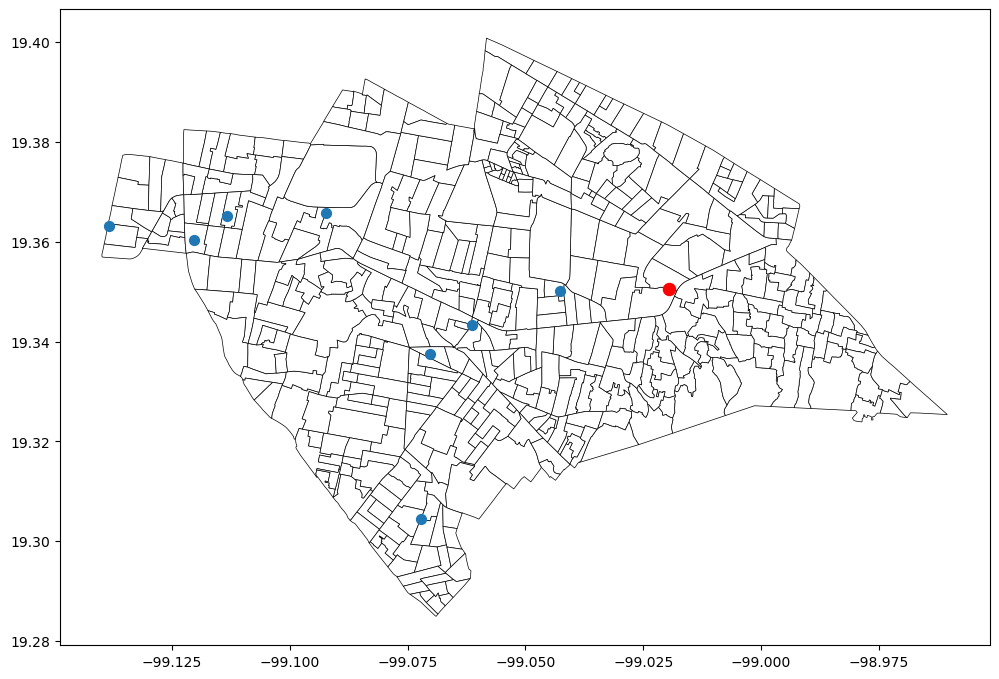

In [325]:
# Annotation: Map a manually chosen root incident over the selected community and Iztapalapa polygons.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
root=gdf2[gdf2['IDS']==8399228.0]
#root=root[root['comunidad']==central_points[0]]
gdf2.plot(ax=ax,markersize=50,legend=True,categorical=True)
root.plot(ax=ax,markersize=75,color='red')


In [326]:
# Annotation: Initialize the first exploratory group from the root incident.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'idCarpeta', 'Año_inicio',
       'Mes_inicio', 'FechaInicio', 'Delito', 'Categoria', 'Sexo', 'Edad',
       'TipoPersona', 'CalidadJuridica', 'competencia', 'Año_hecho',
       'Mes_hecho', 'FechaHecho', 'HoraHecho', 'HoraInicio', 'alcaldia_hechos',
       'municipio_hechos', 'colonia_datos', 'fgj_colonia_registro', 'latitud',
       'longitud', 'ageb', 'shp', 'longitudrad', 'latitudrad', 'grupo_etario',
       'grupo_etario2', 'genero2', 'año', 'comunidad', 'geometry', 'color',
       'CVE', 'pobreza', 'IDS'],
      dtype='object')

In [327]:
# Annotation: Display the initial group record.

grupo

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
198,282.0,54289.0,54916.0,8399228.0,2019.0,Abril,2019-04-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.01944 19.35060),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011710,"(34, 50]",8399228.0


In [328]:
# Annotation: Remove one hard-coded AGEB from the candidate set before group expansion.
gdf3=gdf2[gdf2['CVE'] != '0900700011710']
gdf3
#dftest2

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]",9062831.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]",8843659.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0
205,196.0,37536.0,38000.0,8501840.0,2019.0,Agosto,2019-08-20,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2019.0,5,POINT (-99.06136 19.34324),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011621,"(34, 50]",8501840.0


In [329]:
# Annotation: Record the modal poverty category of the initial group.
listapobreza=[]
listapobreza.extend(grupo['pobreza'].mode())

In [330]:
# Annotation: Display the stored poverty-category list.
listapobreza

['(34, 50]']

In [331]:
# Annotation: Expand group 1 with candidates within the mean-distance threshold and the same poverty category.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos

# Inicializa la columna 'pop_range' en dftest2
#dftest2['pop_range'] = ''

# Itera sobre las filas de dftest2
dftest2=gdf3.copy()
for i in range(len(dftest2)):
    row2 = dftest2.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):

            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



   Unnamed: 0.1    index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
0         282.0  54289.0     54916.0  8399228.0      2019.0      Abril   
1         196.0  37536.0     38000.0  8501840.0      2019.0     Agosto   

  FechaInicio                       Delito         Categoria       Sexo  ...  \
0  2019-04-07  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
1  2019-08-20  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   

   grupo_etario grupo_etario2 genero2     año  comunidad  \
0         19-64             2     1.0  2019.0          5   
1         19-64             2     1.0  2019.0          5   

                     geometry  \
0  POINT (-99.01944 19.35060)   
1  POINT (-99.06136 19.34324)   

                                               color            CVE   pobreza  \
0  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700011710  (34, 50]   
1  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700011621  (34, 50]   

         ID

In [332]:
# Annotation: Inspect the poverty categories included in the expanded group.
grupo['pobreza'].unique().tolist()

['(34, 50]']

In [333]:
# Annotation: Store group member identifiers and report the group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [334]:
# Annotation: Remove group-1 members from the candidate set.
dftest3 = dftest2[~dftest2['IDS'].isin(listaids)]
dftest3['pobreza'].unique()

array(['(18, 34]', '(34, 50]', '[ 0, 18]', '(50, 70]'], dtype=object)

In [382]:
# Annotation: Inspect the remaining candidate records and data types.
dftest3.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 7 entries, 197 to 204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Unnamed: 0.1          7 non-null      float64 
 1   index                 7 non-null      float64 
 2   Unnamed: 0            7 non-null      float64 
 3   idCarpeta             7 non-null      float64 
 4   Año_inicio            7 non-null      float64 
 5   Mes_inicio            7 non-null      object  
 6   FechaInicio           7 non-null      object  
 7   Delito                7 non-null      object  
 8   Categoria             7 non-null      object  
 9   Sexo                  7 non-null      object  
 10  Edad                  7 non-null      float64 
 11  TipoPersona           7 non-null      object  
 12  CalidadJuridica       7 non-null      object  
 13  competencia           7 non-null      object  
 14  Año_hecho             7 non-null      float64 
 15  Mes

<Axes: >

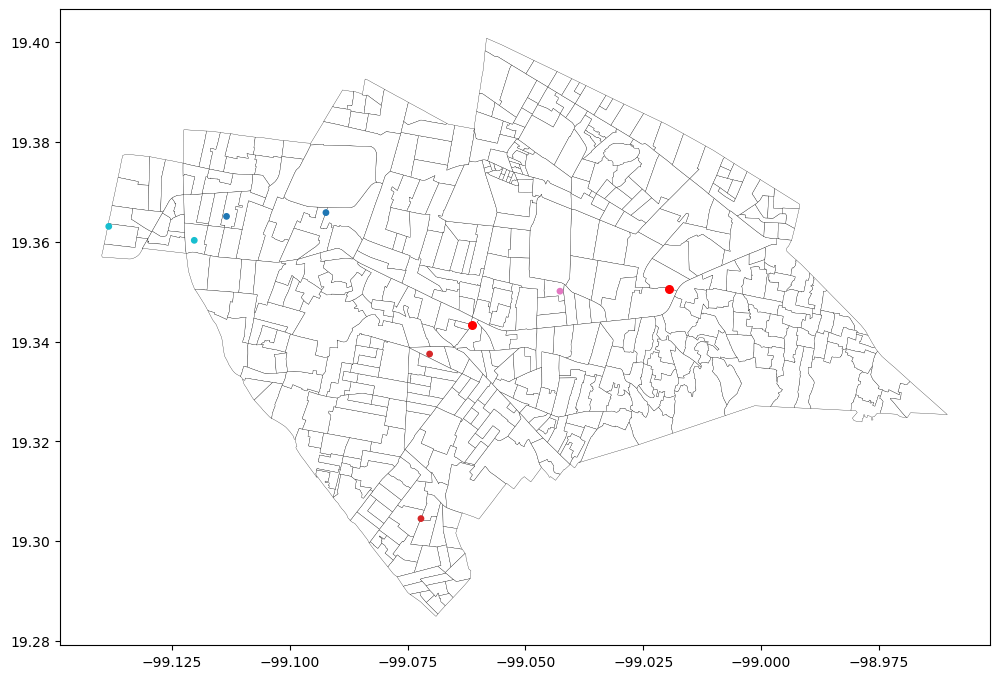

In [337]:
# Annotation: Map group 1 against the remaining candidates, colored by poverty category.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest3.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [338]:
# Annotation: Assign label 1 to the first exploratory group.
grupo['newgroup']=1

In [339]:
# Annotation: Inspect the AGEB layer before transferring group labels to polygons.
alcal

,CVEGEO,POBREZA,POBREZAEX,ID,geometry
0,0900200010010,"(18, 34]","[ 0, 20]",1,"POLYGON ((-99.20307 19.51415, -99.20319 19.513..."
1,0900200010025,"[ 0, 18]","[ 0, 20]",2,"POLYGON ((-99.19662 19.51270, -99.19662 19.511..."
2,090020001003A,"[ 0, 18]","[ 0, 20]",3,"POLYGON ((-99.20658 19.51169, -99.20611 19.511..."
3,0900200010044,"[ 0, 18]","[ 0, 20]",4,"POLYGON ((-99.20530 19.51033, -99.20529 19.510..."
4,0900200010097,"[ 0, 18]","[ 0, 20]",5,"POLYGON ((-99.20573 19.50454, -99.20630 19.504..."
...,...,...,...,...,...
2427,0901700011488,"(34, 50]","[ 0, 20]",2428,"POLYGON ((-99.05931 19.42789, -99.05934 19.427..."
2428,0901700011492,"(34, 50]","[ 0, 20]",2429,"POLYGON ((-99.05931 19.42789, -99.05794 19.426..."
2429,0901700011505,"[ 0, 18]","[ 0, 20]",2430,"POLYGON ((-99.06102 19.42776, -99.05995 19.426..."
2430,090170001151A,"(18, 34]","[ 0, 20]",2431,"POLYGON ((-99.06253 19.42663, -99.06281 19.426..."


## 14. Transfer exploratory group labels to AGEB polygons

The incident-level group number is propagated to AGEB polygons through `CVEGEO`, creating polygon layers for cartographic display. If several incidents from the same AGEB receive different labels, the current `list.index` lookup keeps the first matching label; this should be checked before using the result quantitatively.


In [341]:
# Annotation: Create the polygon layer associated with exploratory group 1.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo1 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()
iztapa['cluster']=''
# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(iztapa)):
    row2 = iztapa.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo1 = pd.concat([alcgrupo1, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo1=gpd.GeoDataFrame(alcgrupo1,geometry=alcgrupo1.geometry)

C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23132\828563774.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [342]:
# Annotation: Count polygons assigned to group 1.
alcgrupo1.cluster.value_counts()

cluster
1    2
Name: count, dtype: int64

In [343]:
# Annotation: Inspect the group-1 polygon GeoDataFrame.
alcgrupo1

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900700011621,"(34, 50]","[ 0, 20]",833,"POLYGON ((-99.06535 19.33905, -99.06501 19.338...",1
1,0900700011710,"(34, 50]","[ 0, 20]",842,"POLYGON ((-99.02431 19.35081, -99.02371 19.350...",1


In [344]:
# Annotation: Propagate group-1 labels back to the complete AGEB layer.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo1)):
    row = alcgrupo1.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

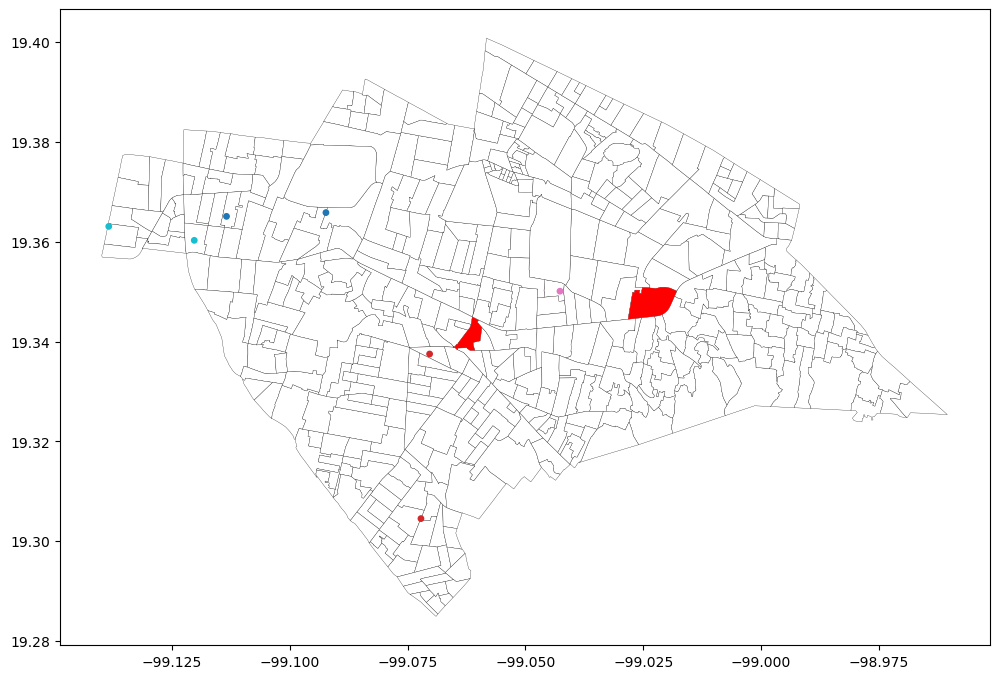

In [346]:
# Annotation: Visualize group-1 polygons together with remaining incident points.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo1.plot(ax=ax,color='red')

dftest3.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [347]:
# Annotation: Inspect the variables retained in the incident-level group table.
grupo.columns

Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'idCarpeta', 'Año_inicio',
       'Mes_inicio', 'FechaInicio', 'Delito', 'Categoria', 'Sexo', 'Edad',
       'TipoPersona', 'CalidadJuridica', 'competencia', 'Año_hecho',
       'Mes_hecho', 'FechaHecho', 'HoraHecho', 'HoraInicio', 'alcaldia_hechos',
       'municipio_hechos', 'colonia_datos', 'fgj_colonia_registro', 'latitud',
       'longitud', 'ageb', 'shp', 'longitudrad', 'latitudrad', 'grupo_etario',
       'grupo_etario2', 'genero2', 'año', 'comunidad', 'geometry', 'color',
       'CVE', 'pobreza', 'IDS', 'newgroup'],
      dtype='object')

In [384]:
# Annotation: Repeat the group-expansion rule using `idCarpeta` directly; this is a redundant exploratory variant.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos

for i in range(len(dftest2)):
    row2 = dftest2.iloc[i]
    ind2 = row2['idCarpeta']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['idCarpeta']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            # Agregar la fila directamente al DataFrame grupo
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)


   Unnamed: 0.1     index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
0        1622.0  314886.0    318120.0  8657148.0      2020.0      Marzo   
1        1525.0  292082.0    295114.0  8632653.0      2020.0    Febrero   
2        1525.0  292082.0    295114.0  8632653.0      2020.0    Febrero   
3        1622.0  314886.0    318120.0  8657148.0      2020.0      Marzo   

  FechaInicio                       Delito         Categoria       Sexo  ...  \
0  2020-03-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
1  2020-02-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
2  2020-02-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
3  2020-03-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   

   grupo_etario grupo_etario2 genero2     año  comunidad  \
0         19-64             2     1.0  2020.0          5   
1         19-64             2     1.0  2020.0          5   
2         19-64             2     1.0  2020

## 15. Incomplete alternative spatial-autocorrelation route

The following cell refers to `pobre` and `alcshp`, which are not defined in the preceding executable path, and its stored output contains an `AttributeError`. It appears to be an unfinished attempt to merge poverty data and construct Queen contiguity weights. It is preserved for provenance but is not part of the validated Louvain workflow.


In [385]:
# Annotation: Attempt an alternative poverty merge and Queen-contiguity weights construction; inputs are incomplete in this notebook.
pobre=pobre.rename(columns={'Clave de \nAGEB':'CVEGEO'})
pobre

alcshppob=pd.merge(alcshp,pobre,on=['CVEGEO'])

from libpysal.weights import Queen

w_queen = Queen.from_dataframe(alcshppob)

AttributeError: 'str' object has no attribute 'rename'

In [348]:
# Annotation: Count poverty categories among the candidates remaining after group 1.
dftest3['pobreza'].value_counts()

pobreza
(18, 34]    2
(34, 50]    2
[ 0, 18]    2
(50, 70]    1
Name: count, dtype: int64

In [350]:
# Annotation: Display the remaining candidate records before constructing group 2.
dftest3

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]",9062831.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]",8843659.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0


In [349]:
# Annotation: Select a new central candidate for the second exploratory group.
central_point = find_central_point_by_community(dftest3, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])

Índices con el valor máximo: []
Punto central: None


In [351]:
# Annotation: Initialize group 2 from a hard-coded root case identifier.
root=dftest3[dftest3['IDS']==9062831.0]
root

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
201,3339.0,685826.0,691817.0,9062831.0,2021.0,Noviembre,2021-11-18,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19-64,2,2.0,2021.0,5,POINT (-99.12028 19.36027),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010939,"[ 0, 18]",9062831.0


<Axes: >

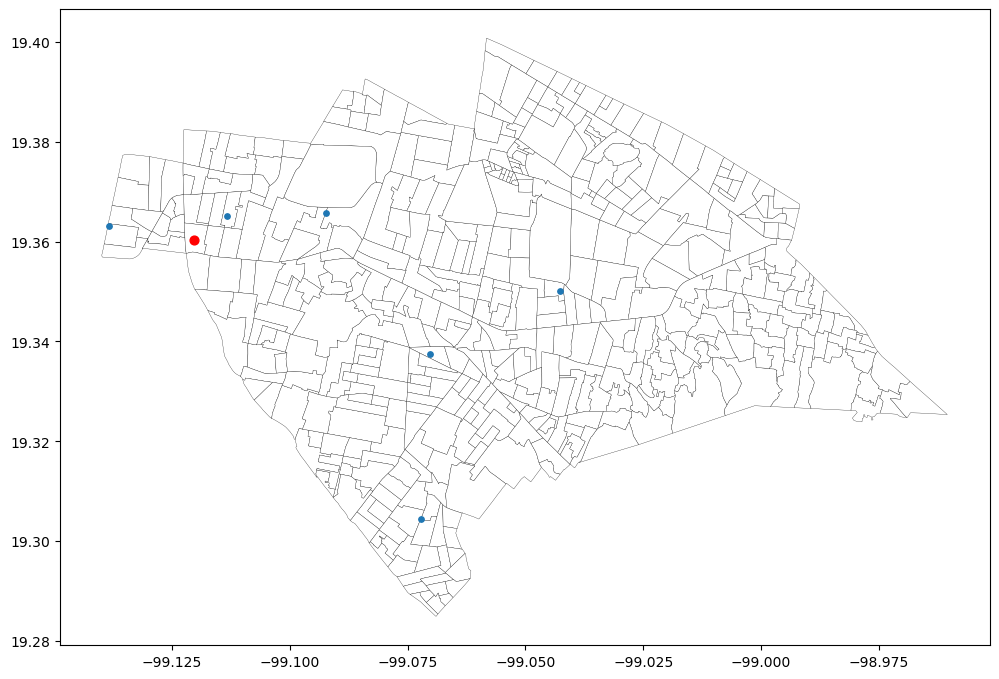

In [352]:
# Annotation: Map the second root against the remaining candidate incidents.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest3.plot(ax=ax,markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [353]:
# Annotation: Initialize the second group GeoDataFrame from the selected root.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'idCarpeta', 'Año_inicio',
       'Mes_inicio', 'FechaInicio', 'Delito', 'Categoria', 'Sexo', 'Edad',
       'TipoPersona', 'CalidadJuridica', 'competencia', 'Año_hecho',
       'Mes_hecho', 'FechaHecho', 'HoraHecho', 'HoraInicio', 'alcaldia_hechos',
       'municipio_hechos', 'colonia_datos', 'fgj_colonia_registro', 'latitud',
       'longitud', 'ageb', 'shp', 'longitudrad', 'latitudrad', 'grupo_etario',
       'grupo_etario2', 'genero2', 'año', 'comunidad', 'geometry', 'color',
       'CVE', 'pobreza', 'IDS'],
      dtype='object')

In [354]:
# Annotation: Inspect the second root's poverty category.
grupo['pobreza']

201    [ 0, 18]
Name: pobreza, dtype: object

In [355]:
# Annotation: Display the previously stored poverty-category list for comparison.
listapobreza

['(34, 50]']

In [356]:
# Annotation: Remove the second root from the candidate set before expansion.
dftest4=dftest3[dftest3['IDS'] != 9062831.0]
dftest4

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
203,2605.0,489902.0,494400.0,8843659.0,2021.0,Enero,2021-01-27,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.13843 19.36306),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010801,"[ 0, 18]",8843659.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0


In [357]:
# Annotation: Expand group 2 using the same mean-distance and equal-poverty conditions.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest4)):
    row2 = dftest4.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



   Unnamed: 0.1     index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
0        3339.0  685826.0    691817.0  9062831.0      2021.0  Noviembre   
1        2605.0  489902.0    494400.0  8843659.0      2021.0      Enero   

  FechaInicio                       Delito         Categoria       Sexo  ...  \
0  2021-11-18  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO   Femenino  ...   
1  2021-01-27  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   

   grupo_etario grupo_etario2 genero2     año  comunidad  \
0         19-64             2     2.0  2021.0          5   
1         19-64             2     1.0  2021.0          5   

                     geometry  \
0  POINT (-99.12028 19.36027)   
1  POINT (-99.13843 19.36306)   

                                               color            CVE   pobreza  \
0  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700010939  [ 0, 18]   
1  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700010801  [ 0, 18]   

        

In [358]:
# Annotation: Inspect poverty categories included in group 2.
grupo['pobreza'].unique()

array(['[ 0, 18]'], dtype=object)

In [359]:
# Annotation: Store group-2 identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [360]:
# Annotation: Remove group-2 members from the remaining candidates.
dftest5 = dftest4[~dftest4['IDS'].isin(listaids)]
dftest5['pobreza'].unique()

array(['(18, 34]', '(34, 50]', '(50, 70]'], dtype=object)

In [361]:
# Annotation: Report the final size of group 2.
len(grupo)

2

<Axes: >

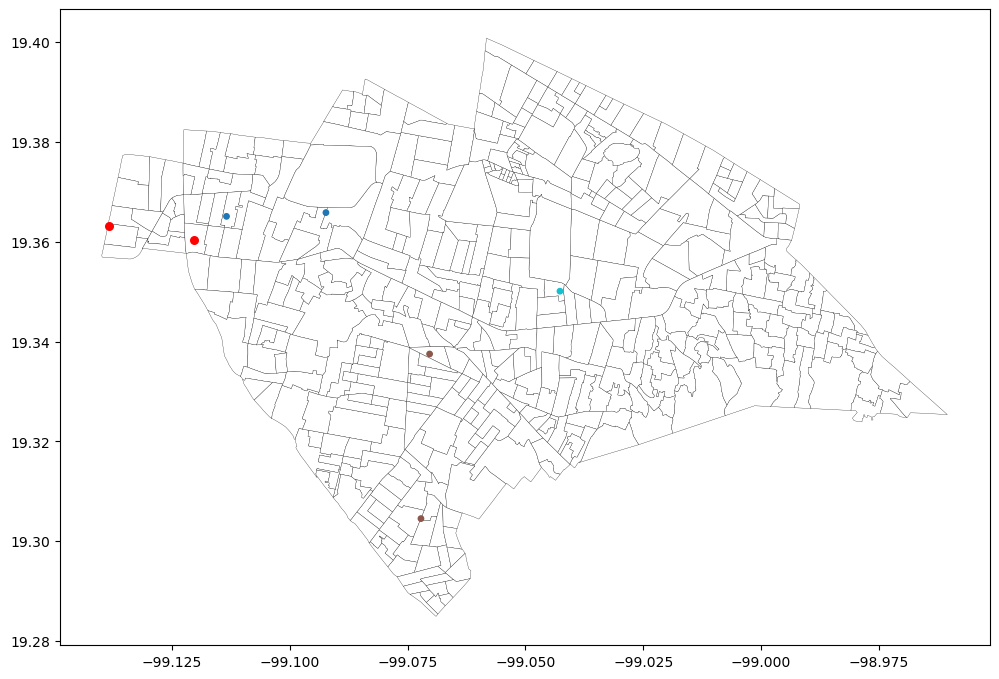

In [362]:
# Annotation: Map group 2 and the still-unassigned incidents.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [363]:
# Annotation: Assign label 2 to the second exploratory group.
grupo['newgroup']=2

In [364]:
# Annotation: Create the AGEB polygon layer associated with group 2.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo2 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(iztapa)):
    row2 = iztapa.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo2 = pd.concat([alcgrupo2, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo2=gpd.GeoDataFrame(alcgrupo2,geometry=alcgrupo2.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23132\2747849927.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


<Axes: >

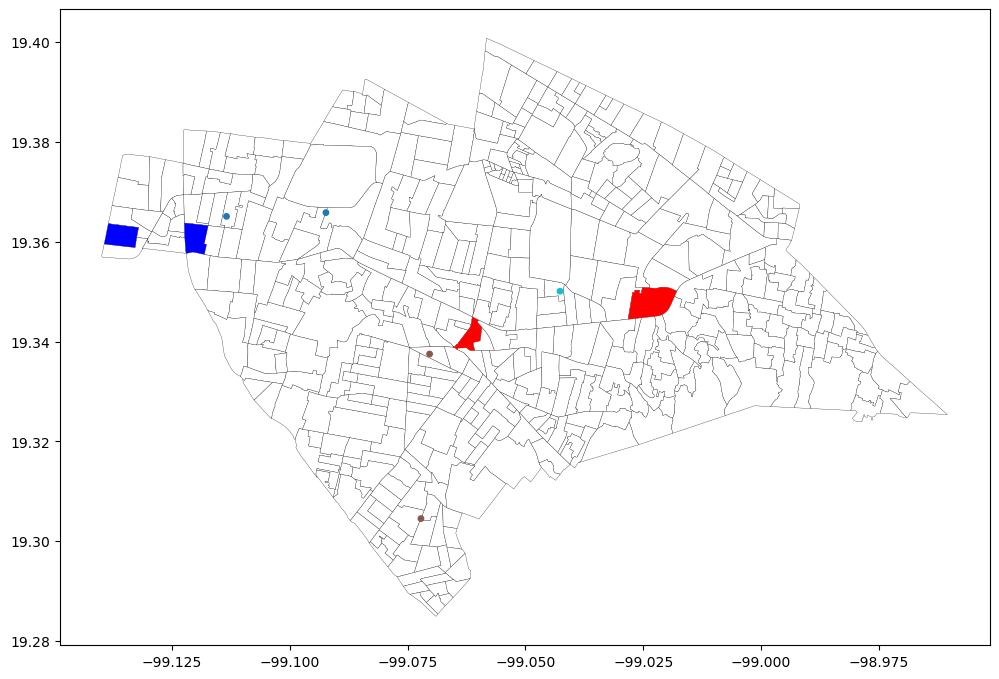

In [365]:
# Annotation: Overlay polygon groups 1 and 2 with the remaining candidate incidents.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [366]:
# Annotation: Inspect poverty categories included in group 2.
grupo['pobreza'].unique()

array(['[ 0, 18]'], dtype=object)

In [367]:
# Annotation: Count poverty categories among incidents not yet assigned to groups 1 or 2.
dftest5['pobreza'].value_counts()

pobreza
(18, 34]    2
(34, 50]    2
(50, 70]    1
Name: count, dtype: int64

In [369]:
# Annotation: Display the remaining candidate records before constructing group 3.
dftest5

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0


In [368]:
# Annotation: Select a central candidate for the third exploratory group.
central_point = find_central_point_by_community(dftest5, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])

Índices con el valor máximo: []
Punto central: None


In [370]:
# Annotation: Initialize group 3 from a hard-coded root case identifier.
root=dftest5[dftest5['IDS']==8657148.0]
root

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
200,1622.0,314886.0,318120.0,8657148.0,2020.0,Marzo,2020-03-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.11344 19.36507),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010708,"(18, 34]",8657148.0


<Axes: >

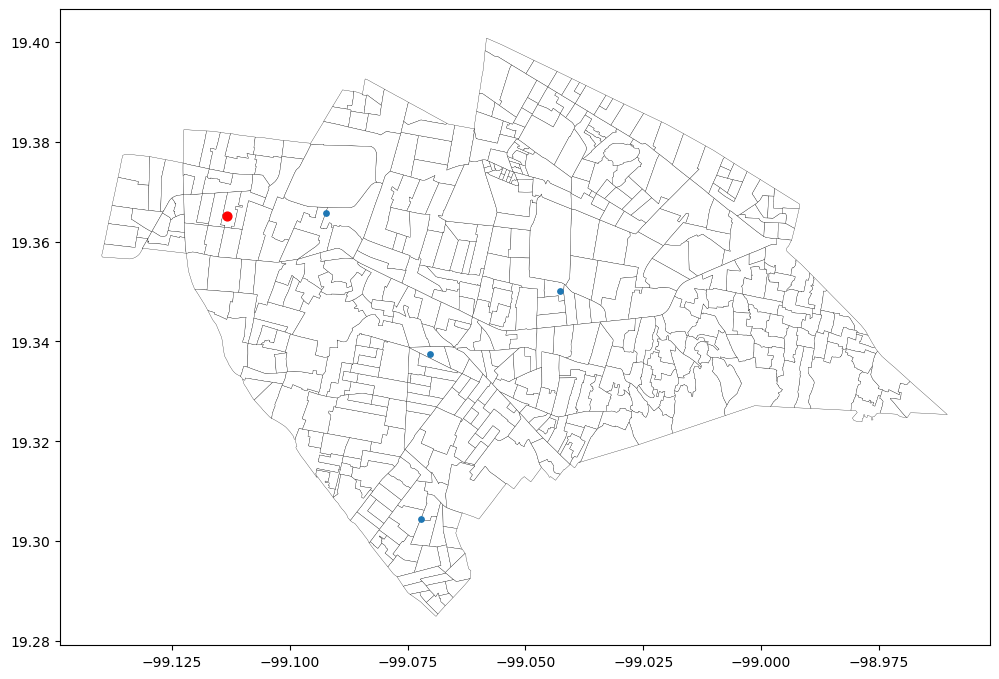

In [372]:
# Annotation: Map the third root against the remaining candidates.
fig,ax=plt.subplots(figsize=(12,10))
iztapa.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest5.plot(ax=ax,markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [373]:
# Annotation: Initialize the third group GeoDataFrame from its root.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'idCarpeta', 'Año_inicio',
       'Mes_inicio', 'FechaInicio', 'Delito', 'Categoria', 'Sexo', 'Edad',
       'TipoPersona', 'CalidadJuridica', 'competencia', 'Año_hecho',
       'Mes_hecho', 'FechaHecho', 'HoraHecho', 'HoraInicio', 'alcaldia_hechos',
       'municipio_hechos', 'colonia_datos', 'fgj_colonia_registro', 'latitud',
       'longitud', 'ageb', 'shp', 'longitudrad', 'latitudrad', 'grupo_etario',
       'grupo_etario2', 'genero2', 'año', 'comunidad', 'geometry', 'color',
       'CVE', 'pobreza', 'IDS'],
      dtype='object')

In [374]:
# Annotation: Inspect the third root's poverty category.
grupo['pobreza']

200    (18, 34]
Name: pobreza, dtype: object

In [375]:
# Annotation: Remove the third root from the candidate set before expansion.
dftest6=dftest5[dftest5['IDS'] != 8657148.0]
dftest6

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,grupo_etario,grupo_etario2,genero2,año,comunidad,geometry,color,CVE,pobreza,IDS
197,1525.0,292082.0,295114.0,8632653.0,2020.0,Febrero,2020-02-13,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2020.0,5,POINT (-99.09234 19.36582),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700010750,"(18, 34]",8632653.0
199,2620.0,495088.0,499620.0,8849170.0,2021.0,Febrero,2021-02-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07217 19.30454),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012117,"(34, 50]",8849170.0
202,3596.0,779615.0,786217.0,9164291.0,2022.0,Abril,2022-04-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2022.0,5,POINT (-99.04266 19.35008),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700011316,"(50, 70]",9164291.0
204,3370.0,693166.0,699214.0,9070654.0,2021.0,Noviembre,2021-11-29,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19-64,2,1.0,2021.0,5,POINT (-99.07033 19.33751),"(0.5490196078431373, 0.33725490196078434, 0.29...",0900700012846,"(34, 50]",9070654.0


In [376]:
# Annotation: Expand group 3 using the mean-distance and equal-poverty conditions.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest6)):
    row2 = dftest6.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



   Unnamed: 0.1     index  Unnamed: 0  idCarpeta  Año_inicio Mes_inicio  \
0        1622.0  314886.0    318120.0  8657148.0      2020.0      Marzo   
1        1525.0  292082.0    295114.0  8632653.0      2020.0    Febrero   

  FechaInicio                       Delito         Categoria       Sexo  ...  \
0  2020-03-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   
1  2020-02-13  HOMICIDIO_POR_ARMA_DE_FUEGO  HOMICIDIO DOLOSO  Masculino  ...   

   grupo_etario grupo_etario2 genero2     año  comunidad  \
0         19-64             2     1.0  2020.0          5   
1         19-64             2     1.0  2020.0          5   

                     geometry  \
0  POINT (-99.11344 19.36507)   
1  POINT (-99.09234 19.36582)   

                                               color            CVE   pobreza  \
0  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700010708  (18, 34]   
1  (0.5490196078431373, 0.33725490196078434, 0.29...  0900700010750  (18, 34]   

        

In [377]:
# Annotation: Inspect poverty categories included in group 3.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [378]:
# Annotation: Store group-3 identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [379]:
# Annotation: Remove group-3 members from the remaining candidates.
dftest7 = dftest6[~dftest6['IDS'].isin(listaids)]
dftest7['pobreza'].unique()

array(['(34, 50]', '(50, 70]'], dtype=object)

In [166]:
# Annotation: Report the final size of group 3.
len(grupo)

3

<Axes: >

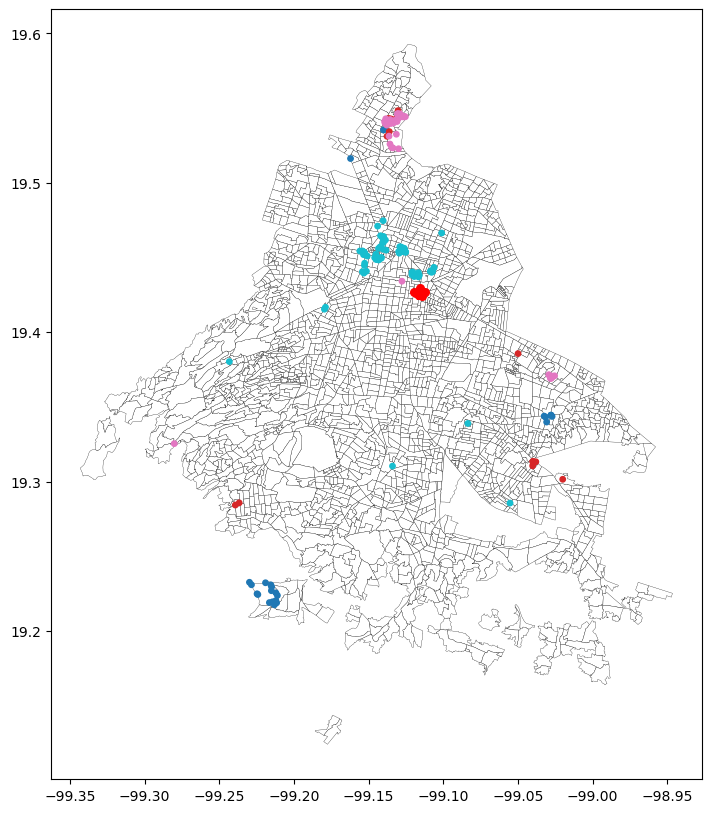

In [141]:
# Annotation: Map group 3 and the remaining unassigned incidents.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest7.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [142]:
# Annotation: Assign label 3 to the third exploratory group.
grupo['newgroup']=3

In [143]:
# Annotation: Create the AGEB polygon layer associated with group 3.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo3 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo3 = pd.concat([alcgrupo3, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo3=gpd.GeoDataFrame(alcgrupo3,geometry=alcgrupo3.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23336\3921591120.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


<Axes: >

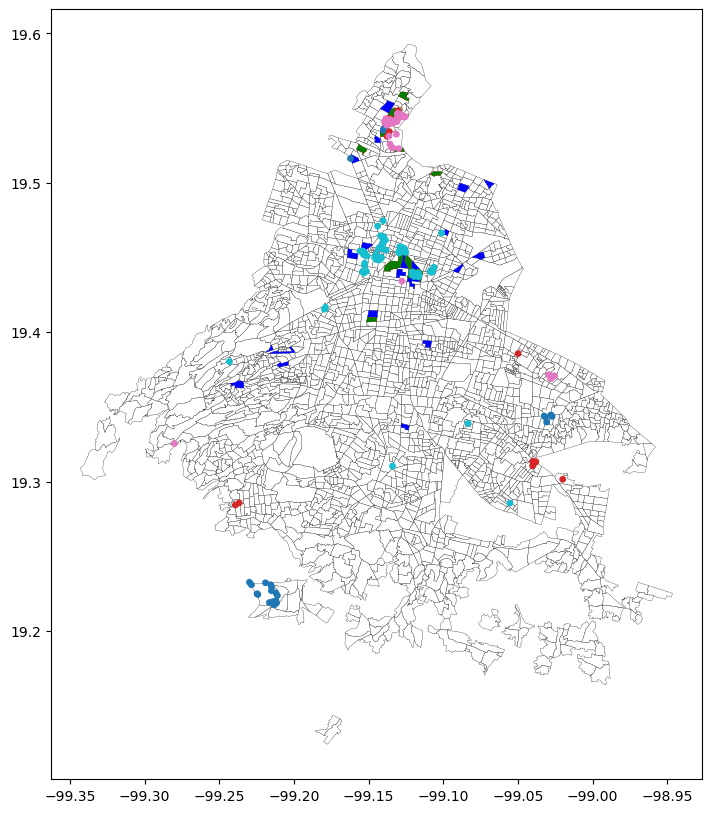

In [144]:
# Annotation: Overlay intermediate polygon groups; the preserved code plots group 1 twice instead of group 3.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo1.plot(ax=ax,color='green')
dftest7.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [145]:
# Annotation: Inspect poverty categories included in group 3.
grupo['pobreza'].unique()

array(['Sin viviendas particulares habitadas'], dtype=object)

In [146]:
# Annotation: Count poverty categories among incidents not assigned to the first three groups.
dftest7['pobreza'].value_counts()

pobreza
[ 0, 18]    73
(50, 70]    44
(18, 34]    26
(34, 50]    15
Name: count, dtype: int64

In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


In [147]:
# Annotation: Select a central candidate for the fourth exploratory group.
central_point = find_central_point_by_community(dftest7, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])

Índices con el valor máximo: ['0901200262297']
Punto central: [393, '0901200262297']
Datos del punto central:
geometry    POINT (-99.2143529745062 19.2194783263529)
CVE                                      0901200262297
pobreza                                       (18, 34]
IDS                                                393
Name: 393, dtype: object


In [148]:
# Annotation: Initialize group 4 from the dynamically selected central case.
root=dftest7[dftest7['IDS']==central_point[0]]
root

,geometry,CVE,pobreza,IDS
393,POINT (-99.21435 19.21948),0901200262297,"(18, 34]",393


<Axes: >

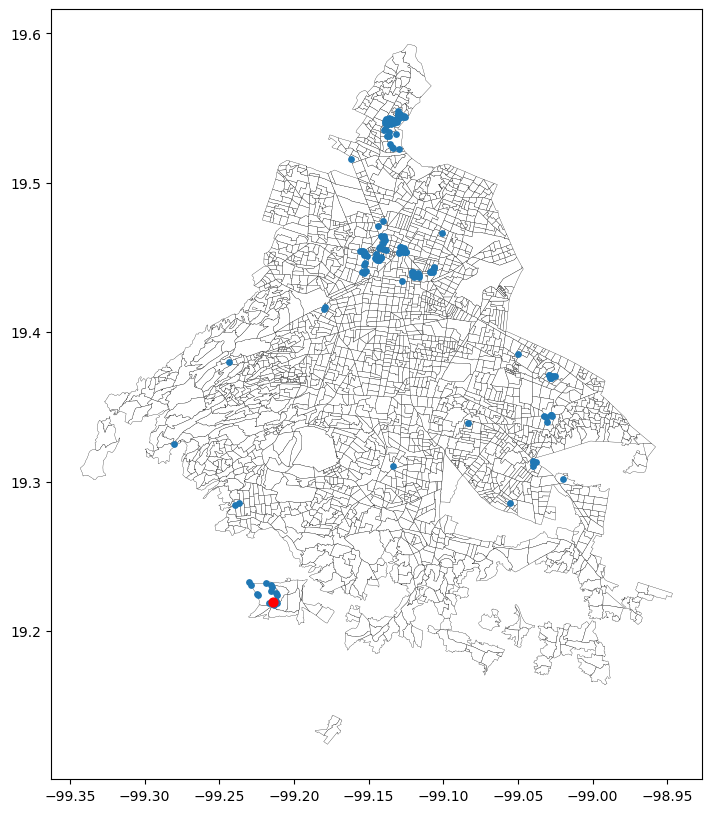

In [149]:
# Annotation: Map the fourth root against the remaining candidates.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest7.plot(ax=ax,markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [150]:
# Annotation: Initialize the fourth group GeoDataFrame from its root.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'CVE', 'pobreza', 'IDS'], dtype='object')

In [151]:
# Annotation: Inspect the fourth root's poverty category.
grupo['pobreza']

393    (18, 34]
Name: pobreza, dtype: object

In [152]:
# Annotation: Remove the fourth root from the candidate set before expansion.
dftest8=dftest7[dftest7['IDS'] != central_point[0]]
dftest8

,geometry,CVE,pobreza,IDS
1,POINT (-99.13660 19.54312),0900500010169,"(34, 50]",1
3,POINT (-99.13882 19.53587),0900500010243,"(18, 34]",3
4,POINT (-99.14006 19.53539),0900500010243,"(18, 34]",4
9,POINT (-99.03155 19.34312),0900700014999,"(18, 34]",9
10,POINT (-99.02009 19.30150),0901100010753,"(34, 50]",10
...,...,...,...,...
537,POINT (-99.12771 19.43413),0901500010771,"(50, 70]",537
541,POINT (-99.13790 19.53864),0900500010205,"(50, 70]",541
545,POINT (-99.13991 19.46326),0901500010080,"[ 0, 18]",545
547,POINT (-99.12674 19.54411),0900500013411,"(50, 70]",547


In [153]:
# Annotation: Expand group 4 using the mean-distance and equal-poverty conditions.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest8)):
    row2 = dftest8.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                      geometry            CVE   pobreza  IDS
0   POINT (-99.21435 19.21948)  0901200262297  (18, 34]  393
1   POINT (-99.21907 19.23223)  0901200261674  (18, 34]   74
2   POINT (-99.22472 19.22486)  0901200262297  (18, 34]  127
3   POINT (-99.21300 19.21854)  0901200262297  (18, 34]  141
4   POINT (-99.22421 19.22435)  0901200262297  (18, 34]  173
5   POINT (-99.21550 19.23082)  0901200262297  (18, 34]  214
6   POINT (-99.21647 19.21896)  0901200262297  (18, 34]  296
7   POINT (-99.22849 19.23090)  0901200262297  (18, 34]  301
8   POINT (-99.22982 19.23256)  0901200262297  (18, 34]  347
9   POINT (-99.21217 19.22026)  0901200262297  (18, 34]  377
10  POINT (-99.21164 19.21880)  0901200262297  (18, 34]  385
11  POINT (-99.21311 19.21745)  0901200262297  (18, 34]  404
12  POINT (-99.21514 19.22692)  0901200262297  (18, 34]  444
13  POINT (-99.21211 19.22546)  0901200262297  (18, 34]  478
14  POINT (-99.21500 19.22944)  0901200262297  (18, 34]  500
15  POINT (-99.21111 19.

In [154]:
# Annotation: Inspect poverty categories included in group 4.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [155]:
# Annotation: Store group-4 identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

16

In [156]:
# Annotation: Remove group-4 members from the remaining candidates.
dftest9 = dftest8[~dftest8['IDS'].isin(listaids)]
dftest9['pobreza'].unique()

array(['(34, 50]', '(18, 34]', '(50, 70]', '[ 0, 18]'], dtype=object)

In [157]:
# Annotation: Report the final size of group 4.
len(grupo)

16

<Axes: >

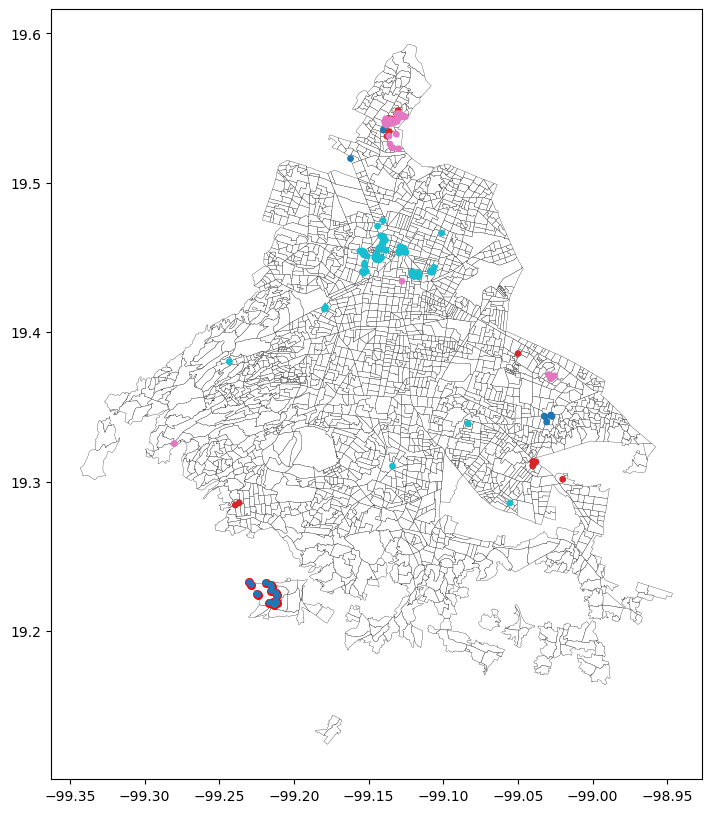

In [158]:
# Annotation: Map group 4; the preserved code overlays `dftest8` rather than the newly filtered `dftest9`.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest8.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [159]:
# Annotation: Assign label 4 to the fourth exploratory group.
grupo['newgroup']=4

In [160]:
# Annotation: Create the AGEB polygon layer associated with group 4.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo4 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo4 = pd.concat([alcgrupo4, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo4=gpd.GeoDataFrame(alcgrupo4,geometry=alcgrupo4.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_23336\984685965.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [ ]:
# Annotation: Empty exploratory cell retained from the original notebook.


## 16. Combined exploratory map

The final figure overlays the four manually generated polygon groups and the remaining unassigned points. It is a diagnostic visualization of the post-processing sequence, not the primary Louvain community map.


<Axes: >

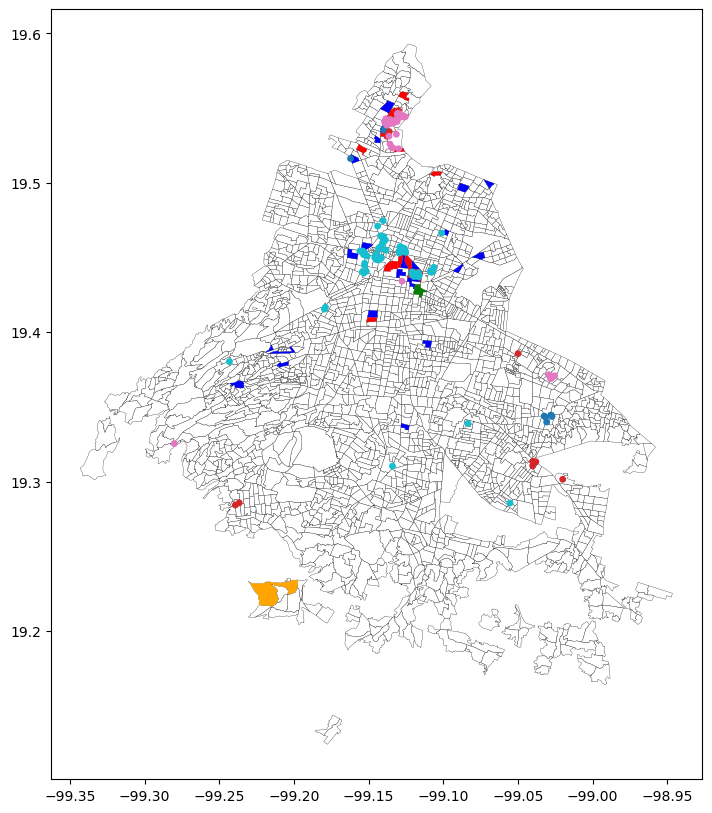

In [164]:
# Annotation: Create the combined diagnostic map of four polygon groups and remaining incidents.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo3.plot(ax=ax,color='green')
alcgrupo4.plot(ax=ax,color='orange')
dftest9.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [163]:
# Annotation: Inspect poverty categories included in the last constructed group.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [ ]:
# Annotation: Empty final cell retained from the original notebook.


## Reproducibility notes and items to review before publication

The notebook is now documented, but the preserved code still contains issues that should be resolved before claiming full end-to-end reproducibility:

1. Missing ages are converted to `0` and therefore classified as `0–18`; missingness should remain separate.
2. With `right=False` and bins `[0, 18, 64, inf]`, the actual intervals are `[0,18)`, `[18,64)`, and `[64,inf)`, which do not match the labels `0–18`, `19–64`, and `65+`.
3. One exploratory inspection references `subG` and `comunidad_dict` before the cells that define them.
4. `max_vecinos=2` is not enforced because the code subsequently adds all neighbours.
5. The community slice `[9:12]`, the selection of community `5`, and several root case identifiers are manually fixed.
6. The distance-matrix labels and GeoDataFrame row indices require alignment.
7. The alternative Queen-contiguity cell has undefined inputs and a stored error.
8. One intermediate map plots `alcgrupo1` twice instead of plotting `alcgrupo3`; another plots `dftest8` where the surrounding sequence suggests `dftest9`.
9. Several assignments operate on filtered DataFrames and may trigger `SettingWithCopyWarning`; explicit `.copy()` calls are advisable.

These notes do not invalidate the stored results, but they identify the exact points that should be checked before rerunning the notebook or releasing it as replication material.
